<a href="https://colab.research.google.com/github/hyunkyung31/coronary-ai-ml-dl/blob/main/hyunkyung/05_AngioCAD_DCA1_UNet256.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#
- 기존 DCA1 5-Fold manifest 재연결
- 256×256 resize 전체 Gate
- Fold 0 DataLoader 검증
- U-Net 구조 동일성 검증
- forward/backward
- Tiny overfit Gate
- 시간이 남으면 Fold 0 Pilot 시작

In [ ]:
#@title 1. 환경 설정 및 Google Drive 연결

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import io
import json
import random
import hashlib

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

DCA1_RESULT_DIR = (
    BASE_DIR
    / "dca1_results"
)

UNET256_DIR = (
    DCA1_RESULT_DIR
    / "unet256_5fold"
)
UNET256_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

print("DCA1 results:", DCA1_RESULT_DIR)
print("U-Net256 results:", UNET256_DIR)

assert DCA1_RESULT_DIR.exists()

print("✅ U-Net256 실험 환경 준비 완료")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
DCA1 results: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results
U-Net256 results: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold
✅ U-Net256 실험 환경 준비 완료


In [ ]:
#@title DCA1 원본 압축파일 탐색·복구

from pathlib import Path
import zipfile

EXTRACT_ROOT = Path("/content/DCA1")
EXTRACT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

archive_candidates = []

for path in BASE_DIR.rglob("*"):
    if not path.is_file():
        continue

    lower_name = path.name.lower()

    if (
        path.suffix.lower() in {
            ".zip",
            ".rar",
            ".7z",
        }
        and (
            "dca1" in lower_name
            or "angiogram" in lower_name
        )
    ):
        archive_candidates.append(path)

print("DCA1 압축파일 후보:", len(archive_candidates))

for index, path in enumerate(
    archive_candidates
):
    print(index, path)

assert len(archive_candidates) >= 1, (
    "Google Drive에서 DCA1 압축파일을 "
    "찾지 못했습니다. 04번 노트북의 "
    "DCA1 다운로드 셀을 먼저 실행하세요."
)

# ZIP 우선
zip_candidates = [
    path
    for path in archive_candidates
    if path.suffix.lower() == ".zip"
]

assert zip_candidates, (
    "DCA1 ZIP 파일을 찾지 못했습니다. "
    "RAR/7z이면 04번 노트북의 압축해제 셀을 "
    "그대로 다시 실행하세요."
)

DCA1_ARCHIVE_PATH = zip_candidates[0]

print("\n사용할 압축파일:")
print(DCA1_ARCHIVE_PATH)

with zipfile.ZipFile(
    DCA1_ARCHIVE_PATH,
    "r",
) as archive:
    archive.extractall(EXTRACT_ROOT)

pgm_files = list(
    EXTRACT_ROOT.rglob("*.pgm")
)

print("복구된 PGM:", len(pgm_files))

assert len(pgm_files) == 268, (
    f"예상 PGM 268개와 다릅니다: "
    f"{len(pgm_files)}"
)

print("✅ DCA1 압축해제 완료")

DCA1 압축파일 후보: 1
0 /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/external_data/DCA1/DB_Angiograms_134.zip

사용할 압축파일:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/external_data/DCA1/DB_Angiograms_134.zip
복구된 PGM: 268
✅ DCA1 압축해제 완료


In [ ]:
#@title 런타임 재시작 후 DCA1 U-Net256 세션 복구

from google.colab import drive
drive.mount(
    "/content/drive",
    force_remount=False,
)

from pathlib import Path
import zipfile
import random

import cv2
import numpy as np
import pandas as pd
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "[MacGyver]최종프로젝트/"
    "03_data/AngioCAD"
)

DCA1_RESULT_DIR = (
    BASE_DIR
    / "dca1_results"
)

UNET256_DIR = (
    DCA1_RESULT_DIR
    / "unet256_5fold"
)
UNET256_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EXTRACT_ROOT = Path("/content/DCA1")
EXTRACT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

# --------------------------------------------------
# 1. /content의 DCA1 원본 복구
# --------------------------------------------------

pgm_files = list(
    EXTRACT_ROOT.rglob("*.pgm")
)

if len(pgm_files) != 268:
    print(
        "DCA1 원본을 다시 압축해제합니다."
    )

    archive_candidates = [
        path
        for path in BASE_DIR.rglob("*.zip")
        if (
            "dca1" in path.name.lower()
            or "angiogram" in path.name.lower()
        )
    ]

    print(
        "DCA1 ZIP 후보:",
        archive_candidates,
    )

    assert archive_candidates, (
        "DCA1 ZIP 파일을 찾지 못했습니다. "
        "04번 노트북의 다운로드 셀을 "
        "다시 실행해야 합니다."
    )

    DCA1_ARCHIVE_PATH = (
        archive_candidates[0]
    )

    with zipfile.ZipFile(
        DCA1_ARCHIVE_PATH,
        "r",
    ) as archive:
        archive.extractall(EXTRACT_ROOT)

pgm_files = list(
    EXTRACT_ROOT.rglob("*.pgm")
)

assert len(pgm_files) == 268, (
    f"PGM 파일 수 오류: {len(pgm_files)}"
)

print("DCA1 PGM:", len(pgm_files))

# --------------------------------------------------
# 2. 저장된 U-Net256 manifest 복구
# --------------------------------------------------

RECOVERED_MANIFEST_PATH = (
    UNET256_DIR
    / "00_dca1_unet256_cv_manifest.csv"
)

assert RECOVERED_MANIFEST_PATH.exists(), (
    "저장된 U-Net256 manifest가 없습니다: "
    f"{RECOVERED_MANIFEST_PATH}"
)

dca1_cv_manifest_df = pd.read_csv(
    RECOVERED_MANIFEST_PATH
)

dca1_cv_manifest_df.columns = [
    str(column).strip()
    for column in dca1_cv_manifest_df.columns
]

def resolve_column(
    dataframe,
    exact_candidates,
    required_tokens=None,
):
    lower_map = {
        column.lower(): column
        for column in dataframe.columns
    }

    for candidate in exact_candidates:
        if candidate.lower() in lower_map:
            return lower_map[
                candidate.lower()
            ]

    if required_tokens:
        for column in dataframe.columns:
            lower_column = column.lower()

            if all(
                token in lower_column
                for token in required_tokens
            ):
                return column

    return None

SAMPLE_ID_COLUMN = resolve_column(
    dca1_cv_manifest_df,
    ["sample_id", "id", "image_id"],
)

FOLD_COLUMN = resolve_column(
    dca1_cv_manifest_df,
    ["cv_fold", "fold"],
    ["fold"],
)

IMAGE_PATH_COLUMN = resolve_column(
    dca1_cv_manifest_df,
    [
        "image_path",
        "image_file_path",
        "original_image_path",
    ],
    ["image", "path"],
)

MASK_PATH_COLUMN = resolve_column(
    dca1_cv_manifest_df,
    [
        "mask_path",
        "mask_file_path",
        "gt_mask_path",
    ],
    ["mask", "path"],
)

assert SAMPLE_ID_COLUMN is not None
assert FOLD_COLUMN is not None
assert IMAGE_PATH_COLUMN is not None
assert MASK_PATH_COLUMN is not None

# --------------------------------------------------
# 3. 현재 /content 경로로 재연결
# --------------------------------------------------

basename_map = {}

for path in pgm_files:
    basename_map.setdefault(
        path.name,
        [],
    ).append(path)

duplicate_names = {
    name: paths
    for name, paths in basename_map.items()
    if len(paths) != 1
}

assert not duplicate_names, (
    "중복 PGM basename이 있습니다: "
    f"{list(duplicate_names)[:10]}"
)

basename_to_path = {
    name: paths[0]
    for name, paths in basename_map.items()
}

resolved_image_paths = []
resolved_mask_paths = []

for _, row in (
    dca1_cv_manifest_df.iterrows()
):
    image_name = Path(
        str(row[IMAGE_PATH_COLUMN])
    ).name

    mask_name = Path(
        str(row[MASK_PATH_COLUMN])
    ).name

    assert image_name in basename_to_path, (
        f"Image 매핑 실패: {image_name}"
    )
    assert mask_name in basename_to_path, (
        f"Mask 매핑 실패: {mask_name}"
    )

    resolved_image_paths.append(
        str(basename_to_path[image_name])
    )
    resolved_mask_paths.append(
        str(basename_to_path[mask_name])
    )

dca1_cv_manifest_df[
    IMAGE_PATH_COLUMN
] = resolved_image_paths

dca1_cv_manifest_df[
    MASK_PATH_COLUMN
] = resolved_mask_paths

dca1_cv_manifest_df[
    FOLD_COLUMN
] = pd.to_numeric(
    dca1_cv_manifest_df[FOLD_COLUMN],
    errors="raise",
).astype(int)

image_exists = (
    dca1_cv_manifest_df[
        IMAGE_PATH_COLUMN
    ]
    .map(lambda value: Path(value).is_file())
)

mask_exists = (
    dca1_cv_manifest_df[
        MASK_PATH_COLUMN
    ]
    .map(lambda value: Path(value).is_file())
)

fold_counts = (
    dca1_cv_manifest_df[
        FOLD_COLUMN
    ]
    .value_counts()
    .sort_index()
    .tolist()
)

assert len(dca1_cv_manifest_df) == 134
assert image_exists.all()
assert mask_exists.all()
assert sorted(fold_counts) == [
    26, 27, 27, 27, 27
]

# 수정된 현재 경로를 다시 저장
dca1_cv_manifest_df.to_csv(
    RECOVERED_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("\nManifest rows:", len(
    dca1_cv_manifest_df
))
print("Image files:", int(
    image_exists.sum()
))
print("Mask files:", int(
    mask_exists.sum()
))
print("Fold sizes:", fold_counts)
print(
    "첫 image:",
    dca1_cv_manifest_df.iloc[0][
        IMAGE_PATH_COLUMN
    ],
)
print(
    "첫 mask:",
    dca1_cv_manifest_df.iloc[0][
        MASK_PATH_COLUMN
    ],
)

print("\n✅ DCA1 U-Net256 세션 복구 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
DCA1 PGM: 268

Manifest rows: 134
Image files: 134
Mask files: 134
Fold sizes: [27, 27, 27, 27, 26]
첫 image: /content/DCA1/Database_134_Angiograms/1.pgm
첫 mask: /content/DCA1/Database_134_Angiograms/1_gt.pgm

✅ DCA1 U-Net256 세션 복구 완료


In [ ]:
#@title 기존 5-Fold manifest 자동 복구

#@title 2. DCA1 5-Fold manifest 자동 탐색 및 원본 Gate

def find_column(
    dataframe,
    exact_candidates,
    required_tokens=None,
):
    lower_map = {
        str(column).strip().lower(): column
        for column in dataframe.columns
    }

    for candidate in exact_candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    if required_tokens:
        for column in dataframe.columns:
            lower_column = (
                str(column)
                .strip()
                .lower()
            )

            if all(
                token in lower_column
                for token in required_tokens
            ):
                return column

    return None

manifest_candidates = []

for csv_path in DCA1_RESULT_DIR.rglob("*.csv"):
    # 기존 U-Net 결과물은 manifest 후보에서 제외
    if "unet128_5fold_raw" in str(csv_path):
        continue

    if "unet256_5fold" in str(csv_path):
        continue

    try:
        candidate_df = pd.read_csv(csv_path)
        candidate_df.columns = [
            str(column).strip()
            for column in candidate_df.columns
        ]

        fold_column = find_column(
            candidate_df,
            ["cv_fold", "fold"],
            ["fold"],
        )

        image_column = find_column(
            candidate_df,
            [
                "image_path",
                "image_file_path",
                "original_image_path",
            ],
            ["image", "path"],
        )

        mask_column = find_column(
            candidate_df,
            [
                "mask_path",
                "mask_file_path",
                "gt_mask_path",
            ],
            ["mask", "path"],
        )

        if (
            len(candidate_df) == 134
            and fold_column is not None
            and image_column is not None
            and mask_column is not None
        ):
            manifest_candidates.append(
                {
                    "path": csv_path,
                    "dataframe": candidate_df,
                    "fold_column": fold_column,
                    "image_column": image_column,
                    "mask_column": mask_column,
                }
            )

    except Exception:
        continue

print(
    "발견된 manifest 후보:",
    len(manifest_candidates),
)

for candidate in manifest_candidates:
    print(candidate["path"])

assert len(manifest_candidates) >= 1, (
    "134개 표본과 cv_fold/image_path/mask_path를 "
    "가진 manifest를 찾지 못했습니다."
)

# 파일명에 cv 또는 fold가 있는 후보 우선
manifest_candidates.sort(
    key=lambda item: (
        0
        if (
            "cv" in item["path"].name.lower()
            or "fold" in item["path"].name.lower()
        )
        else 1,
        len(item["path"].parts),
    )
)

selected = manifest_candidates[0]

DCA1_CV_MANIFEST_PATH = selected["path"]
dca1_cv_manifest_df = (
    selected["dataframe"]
    .copy()
)

FOLD_COLUMN = selected["fold_column"]
IMAGE_PATH_COLUMN = selected["image_column"]
MASK_PATH_COLUMN = selected["mask_column"]

SAMPLE_ID_COLUMN = find_column(
    dca1_cv_manifest_df,
    ["sample_id", "id", "image_id"],
)

if SAMPLE_ID_COLUMN is None:
    dca1_cv_manifest_df["sample_id"] = np.arange(
        len(dca1_cv_manifest_df)
    )
    SAMPLE_ID_COLUMN = "sample_id"

dca1_cv_manifest_df[FOLD_COLUMN] = (
    pd.to_numeric(
        dca1_cv_manifest_df[FOLD_COLUMN],
        errors="raise",
    )
    .astype(int)
)

image_exists = (
    dca1_cv_manifest_df[
        IMAGE_PATH_COLUMN
    ]
    .map(lambda value: Path(str(value)).exists())
)

mask_exists = (
    dca1_cv_manifest_df[
        MASK_PATH_COLUMN
    ]
    .map(lambda value: Path(str(value)).exists())
)

print("\n선택한 manifest:")
print(DCA1_CV_MANIFEST_PATH)

print("\n열 연결:")
print("Sample ID:", SAMPLE_ID_COLUMN)
print("CV fold:", FOLD_COLUMN)
print("Image path:", IMAGE_PATH_COLUMN)
print("Mask path:", MASK_PATH_COLUMN)

print("\nFold 분포:")
print(
    dca1_cv_manifest_df[
        FOLD_COLUMN
    ].value_counts().sort_index()
)

print("\n원본 파일 상태:")
print("존재하는 image:", int(image_exists.sum()))
print("존재하는 mask:", int(mask_exists.sum()))
print(
    "누락 image:",
    int((~image_exists).sum()),
)
print(
    "누락 mask:",
    int((~mask_exists).sum()),
)

if not image_exists.all():
    print("\n누락 image 예시:")
    display(
        dca1_cv_manifest_df.loc[
            ~image_exists,
            [
                SAMPLE_ID_COLUMN,
                IMAGE_PATH_COLUMN,
            ],
        ].head()
    )

if not mask_exists.all():
    print("\n누락 mask 예시:")
    display(
        dca1_cv_manifest_df.loc[
            ~mask_exists,
            [
                SAMPLE_ID_COLUMN,
                MASK_PATH_COLUMN,
            ],
        ].head()
    )

fold_counts = (
    dca1_cv_manifest_df[
        FOLD_COLUMN
    ]
    .value_counts()
    .sort_index()
    .tolist()
)

duplicate_ids = int(
    dca1_cv_manifest_df[
        SAMPLE_ID_COLUMN
    ].duplicated().sum()
)

source_gate_df = pd.DataFrame(
    [
        {
            "check": "manifest_rows",
            "observed": len(
                dca1_cv_manifest_df
            ),
            "expected": 134,
            "status": (
                "PASS"
                if len(
                    dca1_cv_manifest_df
                ) == 134
                else "FAIL"
            ),
        },
        {
            "check": "fold_count",
            "observed": (
                dca1_cv_manifest_df[
                    FOLD_COLUMN
                ].nunique()
            ),
            "expected": 5,
            "status": (
                "PASS"
                if (
                    dca1_cv_manifest_df[
                        FOLD_COLUMN
                    ].nunique() == 5
                )
                else "FAIL"
            ),
        },
        {
            "check": "fold_sizes",
            "observed": str(fold_counts),
            "expected": "[27,27,27,27,26] 순서 무관",
            "status": (
                "PASS"
                if sorted(fold_counts)
                == [26, 27, 27, 27, 27]
                else "FAIL"
            ),
        },
        {
            "check": "duplicate_sample_id",
            "observed": duplicate_ids,
            "expected": 0,
            "status": (
                "PASS"
                if duplicate_ids == 0
                else "FAIL"
            ),
        },
        {
            "check": "missing_image",
            "observed": int(
                (~image_exists).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if image_exists.all()
                else "FAIL"
            ),
        },
        {
            "check": "missing_mask",
            "observed": int(
                (~mask_exists).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if mask_exists.all()
                else "FAIL"
            ),
        },
    ]
)

display(source_gate_df)

SOURCE_GATE_PATH = (
    UNET256_DIR
    / "01_unet256_source_gate.csv"
)

MANIFEST_COPY_PATH = (
    UNET256_DIR
    / "00_dca1_unet256_cv_manifest.csv"
)

source_gate_df.to_csv(
    SOURCE_GATE_PATH,
    index=False,
    encoding="utf-8-sig",
)

dca1_cv_manifest_df.to_csv(
    MANIFEST_COPY_PATH,
    index=False,
    encoding="utf-8-sig",
)

assert (
    source_gate_df["status"] == "PASS"
).all(), (
    "❌ 원본 Gate 실패. 누락 파일을 복구한 후 "
    "다음 셀로 넘어가야 합니다."
)

print("✅ U-Net256 원본 및 Fold Gate 통과")
print("저장:", SOURCE_GATE_PATH)
print("저장:", MANIFEST_COPY_PATH)

발견된 manifest 후보: 1
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/04_dca1_cv_manifest.csv

선택한 manifest:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/04_dca1_cv_manifest.csv

열 연결:
Sample ID: sample_id
CV fold: cv_fold
Image path: image_path
Mask path: mask_path

Fold 분포:
cv_fold
0    27
1    27
2    27
3    27
4    26
Name: count, dtype: int64

원본 파일 상태:
존재하는 image: 134
존재하는 mask: 134
누락 image: 0
누락 mask: 0


,check,observed,expected,status
0,manifest_rows,134,134,PASS
1,fold_count,5,5,PASS
2,fold_sizes,"[27, 27, 27, 27, 26]","[27,27,27,27,26] 순서 무관",PASS
3,duplicate_sample_id,0,0,PASS
4,missing_image,0,0,PASS
5,missing_mask,0,0,PASS


✅ U-Net256 원본 및 Fold Gate 통과
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/01_unet256_source_gate.csv
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/00_dca1_unet256_cv_manifest.csv


In [ ]:
#@title DCA1 PGM 안전 로더 검사

from PIL import Image

def read_dca1_grayscale(path_value):
    path = Path(str(path_value))

    if not path.exists():
        raise FileNotFoundError(
            f"파일 없음: {path}"
        )

    if not path.is_file():
        raise IsADirectoryError(
            f"파일이 아니라 디렉터리입니다: {path}"
        )

    # 우선 원본 dtype 보존
    image = cv2.imread(
        str(path),
        cv2.IMREAD_UNCHANGED,
    )

    # OpenCV가 PGM을 읽지 못하면 PIL 사용
    if image is None:
        try:
            with Image.open(path) as pil_image:
                image = np.asarray(
                    pil_image.convert("L")
                )
        except Exception as error:
            raise RuntimeError(
                f"영상 읽기 실패: {path}"
            ) from error

    image = np.asarray(image)

    if image.ndim == 3:
        if image.shape[-1] == 3:
            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2GRAY,
            )
        elif image.shape[-1] == 4:
            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGRA2GRAY,
            )
        else:
            raise ValueError(
                f"비정상 채널 shape: "
                f"{image.shape}, {path}"
            )

    if image.ndim != 2:
        raise ValueError(
            f"비정상 영상 shape: "
            f"{image.shape}, {path}"
        )

    # 8-bit가 아닌 경우에만 안전하게 0~255 변환
    if image.dtype != np.uint8:
        image_float = image.astype(np.float32)

        minimum = float(image_float.min())
        maximum = float(image_float.max())

        if maximum > minimum:
            image_float = (
                (image_float - minimum)
                / (maximum - minimum)
                * 255.0
            )
        else:
            image_float = np.zeros_like(
                image_float
            )

        image = np.clip(
            image_float,
            0,
            255,
        ).astype(np.uint8)

    return image


first_row = dca1_cv_manifest_df.iloc[0]

first_image_path = Path(
    str(first_row[IMAGE_PATH_COLUMN])
)
first_mask_path = Path(
    str(first_row[MASK_PATH_COLUMN])
)

print("첫 image:", first_image_path)
print(
    "exists/is_file:",
    first_image_path.exists(),
    first_image_path.is_file(),
)
print("첫 mask:", first_mask_path)
print(
    "exists/is_file:",
    first_mask_path.exists(),
    first_mask_path.is_file(),
)

test_image = read_dca1_grayscale(
    first_image_path
)
test_mask = read_dca1_grayscale(
    first_mask_path
)

print(
    "Image:",
    test_image.shape,
    test_image.dtype,
    int(test_image.min()),
    int(test_image.max()),
)
print(
    "Mask:",
    test_mask.shape,
    test_mask.dtype,
    int(test_mask.min()),
    int(test_mask.max()),
)

assert test_image.ndim == 2
assert test_mask.ndim == 2
assert test_image.size > 0
assert test_mask.size > 0

print("✅ DCA1 PGM 안전 로더 검증 통과")

첫 image: /content/DCA1/Database_134_Angiograms/1.pgm
exists/is_file: True True
첫 mask: /content/DCA1/Database_134_Angiograms/1_gt.pgm
exists/is_file: True True
Image: (300, 300) uint8 4 201
Mask: (300, 300) uint8 0 255
✅ DCA1 PGM 안전 로더 검증 통과


In [ ]:
#@title 3. 256×256 resize Gate 및 Fold 0 DataLoader

class DCA1SegmentationDataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_path_column,
        mask_path_column,
        sample_id_column,
        output_size=256,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )
        self.image_path_column = (
            image_path_column
        )
        self.mask_path_column = (
            mask_path_column
        )
        self.sample_id_column = (
            sample_id_column
        )
        self.output_size = output_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = cv2.imread(
            str(row[self.image_path_column]),
            cv2.IMREAD_GRAYSCALE,
        )
        mask = cv2.imread(
            str(row[self.mask_path_column]),
            cv2.IMREAD_GRAYSCALE,
        )

        if image is None:
            raise RuntimeError(
                f"Image 읽기 실패: "
                f"{row[self.image_path_column]}"
            )

        if mask is None:
            raise RuntimeError(
                f"Mask 읽기 실패: "
                f"{row[self.mask_path_column]}"
            )

        image = cv2.resize(
            image,
            (self.output_size, self.output_size),
            interpolation=cv2.INTER_LINEAR,
        )

        mask = cv2.resize(
            mask,
            (self.output_size, self.output_size),
            interpolation=cv2.INTER_NEAREST,
        )

        image_tensor = torch.from_numpy(
            image.astype(np.float32) / 255.0
        ).unsqueeze(0)

        mask_tensor = torch.from_numpy(
            (mask > 0).astype(np.float32)
        ).unsqueeze(0)

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "sample_id": row[
                self.sample_id_column
            ],
        }

resize_audit_rows = []

for _, row in tqdm(
    dca1_cv_manifest_df.iterrows(),
    total=len(dca1_cv_manifest_df),
    desc="DCA1 256 resize 검사",
):
    original_mask = cv2.imread(
        str(row[MASK_PATH_COLUMN]),
        cv2.IMREAD_GRAYSCALE,
    )

    resized_image = cv2.resize(
        cv2.imread(
            str(row[IMAGE_PATH_COLUMN]),
            cv2.IMREAD_GRAYSCALE,
        ),
        (256, 256),
        interpolation=cv2.INTER_LINEAR,
    )

    resized_mask = cv2.resize(
        original_mask,
        (256, 256),
        interpolation=cv2.INTER_NEAREST,
    )

    original_binary = (
        original_mask > 0
    ).astype(np.uint8)

    resized_binary = (
        resized_mask > 0
    ).astype(np.uint8)

    original_rate = float(
        original_binary.mean()
    )
    resized_rate = float(
        resized_binary.mean()
    )

    original_components = (
        cv2.connectedComponents(
            original_binary,
            connectivity=8,
        )[0] - 1
    )

    resized_components = (
        cv2.connectedComponents(
            resized_binary,
            connectivity=8,
        )[0] - 1
    )

    resize_audit_rows.append(
        {
            "sample_id": row[
                SAMPLE_ID_COLUMN
            ],
            "image_shape_valid": (
                resized_image.shape == (256, 256)
            ),
            "mask_shape_valid": (
                resized_binary.shape == (256, 256)
            ),
            "empty_mask": int(
                resized_binary.sum() == 0
            ),
            "original_vessel_rate": (
                original_rate
            ),
            "resized_vessel_rate": (
                resized_rate
            ),
            "relative_vessel_rate_change": (
                (resized_rate - original_rate)
                / max(original_rate, 1e-8)
            ),
            "original_component_count": (
                original_components
            ),
            "resized_component_count": (
                resized_components
            ),
        }
    )

resize_audit_df = pd.DataFrame(
    resize_audit_rows
)

print(
    "축소 후 빈 mask:",
    resize_audit_df["empty_mask"].sum(),
)
print(
    "비정상 image shape:",
    (~resize_audit_df[
        "image_shape_valid"
    ]).sum(),
)
print(
    "비정상 mask shape:",
    (~resize_audit_df[
        "mask_shape_valid"
    ]).sum(),
)

print("\n혈관 비율 상대 변화:")
print(
    resize_audit_df[
        "relative_vessel_rate_change"
    ].describe()
)

print("\nConnected component 변화:")
display(
    resize_audit_df[
        [
            "original_component_count",
            "resized_component_count",
        ]
    ].describe()
)

assert resize_audit_df[
    "empty_mask"
].sum() == 0
assert resize_audit_df[
    "image_shape_valid"
].all()
assert resize_audit_df[
    "mask_shape_valid"
].all()

RESIZE_AUDIT_PATH = (
    UNET256_DIR
    / "02_unet256_resize_audit.csv"
)

resize_audit_df.to_csv(
    RESIZE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

fold0_train_df = (
    dca1_cv_manifest_df.loc[
        dca1_cv_manifest_df[
            FOLD_COLUMN
        ] != 0
    ]
    .reset_index(drop=True)
)

fold0_val_df = (
    dca1_cv_manifest_df.loc[
        dca1_cv_manifest_df[
            FOLD_COLUMN
        ] == 0
    ]
    .reset_index(drop=True)
)

fold0_train_dataset = (
    DCA1SegmentationDataset(
        fold0_train_df,
        IMAGE_PATH_COLUMN,
        MASK_PATH_COLUMN,
        SAMPLE_ID_COLUMN,
        output_size=256,
    )
)

fold0_val_dataset = (
    DCA1SegmentationDataset(
        fold0_val_df,
        IMAGE_PATH_COLUMN,
        MASK_PATH_COLUMN,
        SAMPLE_ID_COLUMN,
        output_size=256,
    )
)

generator = torch.Generator()
generator.manual_seed(SEED)

fold0_train_loader = DataLoader(
    fold0_train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    generator=generator,
)

fold0_val_loader = DataLoader(
    fold0_val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

batch = next(iter(fold0_train_loader))

print("\nTrain samples:", len(fold0_train_dataset))
print("Validation samples:", len(fold0_val_dataset))
print("Image batch:", batch["image"].shape)
print("Mask batch:", batch["mask"].shape)
print(
    "Image range:",
    float(batch["image"].min()),
    float(batch["image"].max()),
)
print(
    "Mask unique:",
    torch.unique(batch["mask"]),
)

assert batch["image"].shape == (
    4, 1, 256, 256
)
assert batch["mask"].shape == (
    4, 1, 256, 256
)
assert torch.isfinite(batch["image"]).all()
assert set(
    torch.unique(
        batch["mask"]
    ).tolist()
).issubset({0.0, 1.0})

print("✅ U-Net256 resize/DataLoader Gate 통과")
print("저장:", RESIZE_AUDIT_PATH)

DCA1 256 resize 검사:   0%|          | 0/134 [00:00<?, ?it/s]

축소 후 빈 mask: 0
비정상 image shape: 0
비정상 mask shape: 0

혈관 비율 상대 변화:
count    134.000000
mean       0.001755
std        0.007702
min       -0.018426
25%       -0.003487
50%        0.001738
75%        0.005622
max        0.030938
Name: relative_vessel_rate_change, dtype: float64

Connected component 변화:


,original_component_count,resized_component_count
count,134.000000,134.000000
mean,1.052239,1.313433
std,0.308213,1.014318
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,4.000000,8.000000



Train samples: 107
Validation samples: 27
Image batch: torch.Size([4, 1, 256, 256])
Mask batch: torch.Size([4, 1, 256, 256])
Image range: 0.0 0.9137254953384399
Mask unique: tensor([0., 1.])
✅ U-Net256 resize/DataLoader Gate 통과
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/02_unet256_resize_audit.csv


In [ ]:
#@title 4. U-Net256 구조동일성 forward/backward Gate

class DoubleConv(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        base_channels=32,
    ):
        super().__init__()

        b = base_channels

        self.encoder1 = DoubleConv(
            in_channels, b
        )
        self.encoder2 = DoubleConv(
            b, b * 2
        )
        self.encoder3 = DoubleConv(
            b * 2, b * 4
        )
        self.encoder4 = DoubleConv(
            b * 4, b * 8
        )
        self.bottleneck = DoubleConv(
            b * 8, b * 16
        )

        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(
            b * 16,
            b * 8,
            kernel_size=2,
            stride=2,
        )
        self.decoder4 = DoubleConv(
            b * 16, b * 8
        )

        self.up3 = nn.ConvTranspose2d(
            b * 8,
            b * 4,
            kernel_size=2,
            stride=2,
        )
        self.decoder3 = DoubleConv(
            b * 8, b * 4
        )

        self.up2 = nn.ConvTranspose2d(
            b * 4,
            b * 2,
            kernel_size=2,
            stride=2,
        )
        self.decoder2 = DoubleConv(
            b * 4, b * 2
        )

        self.up1 = nn.ConvTranspose2d(
            b * 2,
            b,
            kernel_size=2,
            stride=2,
        )
        self.decoder1 = DoubleConv(
            b * 2, b
        )

        self.output = nn.Conv2d(
            b,
            out_channels,
            kernel_size=1,
        )

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool(e1))
        e3 = self.encoder3(self.pool(e2))
        e4 = self.encoder4(self.pool(e3))

        bottleneck = self.bottleneck(
            self.pool(e4)
        )

        d4 = self.up4(bottleneck)
        d4 = self.decoder4(
            torch.cat([d4, e4], dim=1)
        )

        d3 = self.up3(d4)
        d3 = self.decoder3(
            torch.cat([d3, e3], dim=1)
        )

        d2 = self.up2(d3)
        d2 = self.decoder2(
            torch.cat([d2, e2], dim=1)
        )

        d1 = self.up1(d2)
        d1 = self.decoder1(
            torch.cat([d1, e1], dim=1)
        )

        return self.output(d1)


class FocalTverskyLoss(nn.Module):
    def __init__(
        self,
        alpha=0.3,
        beta=0.7,
        gamma=0.75,
        smooth=1e-6,
    ):
        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        probabilities = torch.sigmoid(logits)

        probabilities = probabilities.view(
            probabilities.size(0),
            -1,
        )
        targets = targets.view(
            targets.size(0),
            -1,
        )

        true_positive = (
            probabilities * targets
        ).sum(dim=1)

        false_positive = (
            probabilities * (1 - targets)
        ).sum(dim=1)

        false_negative = (
            (1 - probabilities) * targets
        ).sum(dim=1)

        tversky = (
            true_positive + self.smooth
        ) / (
            true_positive
            + self.alpha * false_positive
            + self.beta * false_negative
            + self.smooth
        )

        return (
            (1 - tversky) ** self.gamma
        ).mean()


torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model256 = UNet().to(DEVICE)

parameter_count = sum(
    parameter.numel()
    for parameter in model256.parameters()
)

print("Parameters:", parameter_count)

# 128 모델과 완전히 동일한 구조여야 함
assert parameter_count == 7_762_465

criterion = FocalTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=0.75,
)

images = batch["image"].to(
    DEVICE,
    non_blocking=True,
)
masks = batch["mask"].to(
    DEVICE,
    non_blocking=True,
)

model256.train()
model256.zero_grad(set_to_none=True)

logits = model256(images)
loss = criterion(logits, masks)
loss.backward()

gradient_finite = all(
    parameter.grad is None
    or torch.isfinite(
        parameter.grad
    ).all().item()
    for parameter in model256.parameters()
)

print("Logits shape:", logits.shape)
print(
    "Initial loss:",
    float(loss.detach().cpu()),
)
print("Gradient finite:", gradient_finite)

if torch.cuda.is_available():
    print(
        "Allocated GPU memory (GB):",
        torch.cuda.max_memory_allocated()
        / 1024**3,
    )

assert logits.shape == masks.shape
assert torch.isfinite(logits).all()
assert torch.isfinite(loss)
assert gradient_finite

buffer = io.BytesIO()
torch.save(
    model256.state_dict(),
    buffer,
)

initial_state_hash = hashlib.sha256(
    buffer.getvalue()
).hexdigest()

model_spec = {
    "experiment": "DCA1_UNet256",
    "input_resolution": [256, 256],
    "architecture": (
        "Same U-Net architecture as U-Net128"
    ),
    "parameter_count": parameter_count,
    "loss": "FocalTverskyLoss",
    "loss_alpha": 0.3,
    "loss_beta": 0.7,
    "loss_gamma": 0.75,
    "training_batch_size": 4,
    "comparison_reference": (
        "U-Net128 raw 5-fold baseline"
    ),
    "initial_state_sha256": initial_state_hash,
    "seed": SEED,
}

MODEL_SPEC_PATH = (
    UNET256_DIR
    / "03_unet256_model_spec.json"
)

with open(
    MODEL_SPEC_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_spec,
        file,
        ensure_ascii=False,
        indent=2,
    )

del logits, loss
model256.zero_grad(set_to_none=True)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Model initial SHA-256:", initial_state_hash)
print("✅ U-Net256 forward/backward Gate 통과")
print("저장:", MODEL_SPEC_PATH)

Parameters: 7762465
Logits shape: torch.Size([4, 1, 256, 256])
Initial loss: 0.8887559175491333
Gradient finite: True
Allocated GPU memory (GB): 0.8496780395507812
Model initial SHA-256: b26e123395152de02d6225f2c91c1ed70e7cb5d46ce40ba0212e03b9823525b6
✅ U-Net256 forward/backward Gate 통과
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/03_unet256_model_spec.json


In [ ]:
#@title 5. U-Net256 Tiny overfit Gate

def segmentation_metrics(
    probabilities,
    targets,
    threshold=0.5,
    epsilon=1e-8,
):
    predictions = (
        probabilities >= threshold
    ).float()

    tp = (
        predictions * targets
    ).sum()

    fp = (
        predictions * (1 - targets)
    ).sum()

    fn = (
        (1 - predictions) * targets
    ).sum()

    tn = (
        (1 - predictions) * (1 - targets)
    ).sum()

    dice = (
        2 * tp + epsilon
    ) / (
        2 * tp + fp + fn + epsilon
    )

    iou = (
        tp + epsilon
    ) / (
        tp + fp + fn + epsilon
    )

    precision = (
        tp + epsilon
    ) / (
        tp + fp + epsilon
    )

    recall = (
        tp + epsilon
    ) / (
        tp + fn + epsilon
    )

    specificity = (
        tn + epsilon
    ) / (
        tn + fp + epsilon
    )

    return {
        "dice": float(dice.detach().cpu()),
        "iou": float(iou.detach().cpu()),
        "precision": float(
            precision.detach().cpu()
        ),
        "recall": float(
            recall.detach().cpu()
        ),
        "specificity": float(
            specificity.detach().cpu()
        ),
    }

tiny_samples = [
    fold0_train_dataset[index]
    for index in [0, 1, 2, 3]
]

tiny_images = torch.stack(
    [
        sample["image"]
        for sample in tiny_samples
    ]
).to(DEVICE)

tiny_masks = torch.stack(
    [
        sample["mask"]
        for sample in tiny_samples
    ]
).to(DEVICE)

tiny_sample_ids = [
    sample["sample_id"]
    for sample in tiny_samples
]

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

tiny_model = UNet().to(DEVICE)

tiny_optimizer = torch.optim.Adam(
    tiny_model.parameters(),
    lr=1e-4,
)

tiny_criterion = FocalTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=0.75,
)

history_rows = []

tiny_model.train()

with torch.no_grad():
    initial_logits = tiny_model(tiny_images)
    initial_loss = float(
        tiny_criterion(
            initial_logits,
            tiny_masks,
        ).detach().cpu()
    )

print("Tiny sample IDs:", tiny_sample_ids)
print("Tiny images:", tiny_images.shape)
print("Initial loss:", initial_loss)

gate_reached = False

for step in range(1, 301):
    tiny_optimizer.zero_grad(
        set_to_none=True
    )

    logits = tiny_model(tiny_images)

    loss = tiny_criterion(
        logits,
        tiny_masks,
    )

    loss.backward()
    tiny_optimizer.step()

    with torch.no_grad():
        probabilities_tiny = torch.sigmoid(
            tiny_model(tiny_images)
        )

        metrics = segmentation_metrics(
            probabilities_tiny,
            tiny_masks,
            threshold=0.5,
        )

    history_rows.append(
        {
            "step": step,
            "loss": float(
                loss.detach().cpu()
            ),
            **metrics,
        }
    )

    if step == 1 or step % 25 == 0:
        print(
            f"step={step:04d} "
            f"loss={history_rows[-1]['loss']:.6f} "
            f"dice={metrics['dice']:.4f} "
            f"precision={metrics['precision']:.4f} "
            f"recall={metrics['recall']:.4f}"
        )

    if (
        metrics["dice"] >= 0.95
        and history_rows[-1]["loss"]
        < initial_loss
    ):
        gate_reached = True
        print(
            "Tiny overfit 조기 종료 조건 도달"
        )
        break

tiny_history_df = pd.DataFrame(
    history_rows
)

final_row = tiny_history_df.iloc[-1]

print("\n=== U-Net256 Tiny overfit 결과 ===")
print("Initial loss:", initial_loss)
print("Final loss:", final_row["loss"])
print("Final Dice:", final_row["dice"])
print("Final IoU:", final_row["iou"])
print("Gate reached:", gate_reached)

TINY_AUDIT_PATH = (
    UNET256_DIR
    / "04_unet256_tiny_overfit_audit.csv"
)

TINY_GATE_PATH = (
    UNET256_DIR
    / "05_unet256_tiny_overfit_gate.csv"
)

tiny_history_df.to_csv(
    TINY_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

tiny_gate_df = pd.DataFrame(
    [
        {
            "check": "loss_decreased",
            "observed": float(
                final_row["loss"]
            ),
            "expected": (
                f"< {initial_loss:.6f}"
            ),
            "status": (
                "PASS"
                if final_row["loss"]
                < initial_loss
                else "FAIL"
            ),
        },
        {
            "check": "tiny_dice",
            "observed": float(
                final_row["dice"]
            ),
            "expected": ">= 0.95",
            "status": (
                "PASS"
                if final_row["dice"] >= 0.95
                else "FAIL"
            ),
        },
        {
            "check": "finite_metrics",
            "observed": int(
                np.isfinite(
                    tiny_history_df[
                        [
                            "loss",
                            "dice",
                            "iou",
                        ]
                    ].to_numpy()
                ).all()
            ),
            "expected": 1,
            "status": (
                "PASS"
                if np.isfinite(
                    tiny_history_df[
                        [
                            "loss",
                            "dice",
                            "iou",
                        ]
                    ].to_numpy()
                ).all()
                else "FAIL"
            ),
        },
    ]
)

tiny_gate_df.to_csv(
    TINY_GATE_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(tiny_gate_df)

assert (
    tiny_gate_df["status"] == "PASS"
).all(), (
    "Tiny overfit Gate 실패. "
    "전체 학습을 시작하지 마세요."
)

print("✅ U-Net256 Tiny overfit Gate 통과")
print("저장:", TINY_AUDIT_PATH)
print("저장:", TINY_GATE_PATH)

Tiny sample IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Tiny images: torch.Size([4, 1, 256, 256])
Initial loss: 0.9058948755264282
step=0001 loss=0.905895 dice=0.0849 precision=0.0444 recall=0.9961
step=0025 loss=0.816191 dice=0.2912 precision=0.1704 recall=0.9992
step=0050 loss=0.786004 dice=0.5808 precision=0.4093 recall=1.0000
step=0075 loss=0.774632 dice=0.6893 precision=0.5259 recall=1.0000
step=0100 loss=0.769105 dice=0.7576 precision=0.6098 recall=1.0000
step=0125 loss=0.765165 dice=0.7950 precision=0.6598 recall=1.0000
step=0150 loss=0.761922 dice=0.8160 precision=0.6893 recall=1.0000
step=0175 loss=0.758497 dice=0.8436 precision=0.7294 recall=1.0000
step=0200 loss=0.755447 dice=0.8635 precision=0.7598 recall=1.0000
step=0225 loss=0.752890 dice=0.8649 precision=0.7620 recall=1.0000
step=0250 loss=0.749715 dice=0.8963 precision=0.8121 recall=1.0000
step=0275 loss=0.746865 dice=0.9118 precision=0.8380 recall=1.0000
step=0300 loss=0.744248 dice=0.9137 precision=0.841

,check,observed,expected,status
0,loss_decreased,0.744248,< 0.905895,PASS
1,tiny_dice,0.913737,>= 0.95,FAIL
2,finite_metrics,1.000000,1,PASS


AssertionError: Tiny overfit Gate 실패. 전체 학습을 시작하지 마세요.

In [ ]:
#@title U-Net256 Tiny overfit 연장 — 현재 모델에서 계속 학습

# 현재 세션의 Tiny 학습 상태 확인
required_variables = [
    "tiny_model",
    "tiny_optimizer",
    "tiny_criterion",
    "tiny_images",
    "tiny_masks",
    "tiny_history_df",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

assert not missing_variables, (
    "Tiny 학습 변수가 없습니다: "
    f"{missing_variables}\n"
    "런타임이 유지된 상태에서 실행해야 합니다."
)

initial_loss_value = (
    float(initial_loss)
    if "initial_loss" in globals()
    else 0.9058948755264282
)

extended_history_rows = (
    tiny_history_df
    .copy()
    .to_dict("records")
)

start_step = (
    int(tiny_history_df["step"].max())
    + 1
)

maximum_step = 700
gate_reached = False

print("이어갈 시작 step:", start_step)
print("최대 step:", maximum_step)

tiny_model.train()

for step in range(
    start_step,
    maximum_step + 1,
):
    tiny_optimizer.zero_grad(
        set_to_none=True
    )

    logits = tiny_model(tiny_images)

    loss = tiny_criterion(
        logits,
        tiny_masks,
    )

    loss.backward()
    tiny_optimizer.step()

    # optimizer update 이후 fresh logits로 검사
    with torch.no_grad():
        fresh_logits = tiny_model(
            tiny_images
        )

        fresh_probabilities = torch.sigmoid(
            fresh_logits
        )

        metrics = segmentation_metrics(
            fresh_probabilities,
            tiny_masks,
            threshold=0.5,
        )

    current_row = {
        "step": step,
        "loss": float(
            loss.detach().cpu()
        ),
        **metrics,
    }

    extended_history_rows.append(
        current_row
    )

    if step % 25 == 0:
        print(
            f"step={step:04d} "
            f"loss={current_row['loss']:.6f} "
            f"dice={metrics['dice']:.4f} "
            f"precision={metrics['precision']:.4f} "
            f"recall={metrics['recall']:.4f}"
        )

    if (
        metrics["dice"] >= 0.95
        and current_row["loss"]
        < initial_loss_value
    ):
        gate_reached = True

        print(
            "\nTiny overfit 조기 종료 조건 도달:",
            step,
        )
        break

extended_history_df = pd.DataFrame(
    extended_history_rows
)

# --------------------------------------------------
# 최종 결과는 반드시 fresh forward로 재검증
# --------------------------------------------------

tiny_model.eval()

with torch.no_grad():
    final_logits = tiny_model(
        tiny_images
    )

    final_probabilities = torch.sigmoid(
        final_logits
    )

    final_eval_loss = float(
        tiny_criterion(
            final_logits,
            tiny_masks,
        )
        .detach()
        .cpu()
    )

    final_eval_metrics = (
        segmentation_metrics(
            final_probabilities,
            tiny_masks,
            threshold=0.5,
        )
    )

print("\n=== U-Net256 Tiny overfit 최종 재검증 ===")
print("Initial loss:", initial_loss_value)
print("Final eval loss:", final_eval_loss)
print(
    "Final eval metrics:",
    final_eval_metrics,
)

TINY_AUDIT_PATH = (
    UNET256_DIR
    / "04_unet256_tiny_overfit_audit.csv"
)

TINY_GATE_PATH = (
    UNET256_DIR
    / "05_unet256_tiny_overfit_gate.csv"
)

extended_history_df.to_csv(
    TINY_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

tiny_gate_df = pd.DataFrame(
    [
        {
            "check": "loss_decreased",
            "observed": final_eval_loss,
            "expected": (
                f"< {initial_loss_value:.6f}"
            ),
            "status": (
                "PASS"
                if final_eval_loss
                < initial_loss_value
                else "FAIL"
            ),
        },
        {
            "check": "eval_dice",
            "observed": (
                final_eval_metrics["dice"]
            ),
            "expected": ">= 0.95",
            "status": (
                "PASS"
                if final_eval_metrics[
                    "dice"
                ] >= 0.95
                else "FAIL"
            ),
        },
        {
            "check": "eval_precision",
            "observed": (
                final_eval_metrics[
                    "precision"
                ]
            ),
            "expected": ">= 0.90",
            "status": (
                "PASS"
                if final_eval_metrics[
                    "precision"
                ] >= 0.90
                else "FAIL"
            ),
        },
        {
            "check": "eval_recall",
            "observed": (
                final_eval_metrics["recall"]
            ),
            "expected": ">= 0.90",
            "status": (
                "PASS"
                if final_eval_metrics[
                    "recall"
                ] >= 0.90
                else "FAIL"
            ),
        },
        {
            "check": "finite_history",
            "observed": int(
                np.isfinite(
                    extended_history_df[
                        [
                            "loss",
                            "dice",
                            "iou",
                            "precision",
                            "recall",
                        ]
                    ].to_numpy()
                ).all()
            ),
            "expected": 1,
            "status": (
                "PASS"
                if np.isfinite(
                    extended_history_df[
                        [
                            "loss",
                            "dice",
                            "iou",
                            "precision",
                            "recall",
                        ]
                    ].to_numpy()
                ).all()
                else "FAIL"
            ),
        },
    ]
)

display(tiny_gate_df)

tiny_gate_df.to_csv(
    TINY_GATE_PATH,
    index=False,
    encoding="utf-8-sig",
)

assert (
    tiny_gate_df["status"] == "PASS"
).all(), (
    "Tiny overfit 연장 후에도 Gate 실패입니다. "
    "전체 Fold 학습은 아직 시작하지 마세요."
)

print("\n✅ U-Net256 Tiny overfit Gate 통과")
print("저장:", TINY_AUDIT_PATH)
print("저장:", TINY_GATE_PATH)

이어갈 시작 step: 301
최대 step: 700
step=0325 loss=0.741171 dice=0.9348 precision=0.8776 recall=1.0000
step=0350 loss=0.738308 dice=0.9462 precision=0.8979 recall=1.0000
step=0375 loss=0.735961 dice=0.9420 precision=0.8903 recall=1.0000

Tiny overfit 조기 종료 조건 도달: 388

=== U-Net256 Tiny overfit 최종 재검증 ===
Initial loss: 0.9058948755264282
Final eval loss: 0.7338535785675049
Final eval metrics: {'dice': 0.9525431990623474, 'iou': 0.9093866348266602, 'precision': 0.9093866348266602, 'recall': 1.0, 'specificity': 0.9954444169998169}


,check,observed,expected,status
0,loss_decreased,0.733854,< 0.905895,PASS
1,eval_dice,0.952543,>= 0.95,PASS
2,eval_precision,0.909387,>= 0.90,PASS
3,eval_recall,1.000000,>= 0.90,PASS
4,finite_history,1.000000,1,PASS



✅ U-Net256 Tiny overfit Gate 통과
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/04_unet256_tiny_overfit_audit.csv
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/05_unet256_tiny_overfit_gate.csv


In [ ]:
#@title 6. U-Net256 학습 Batch Size 자원 Gate

from torch.utils.data import DataLoader

def test_training_batch_size(
    batch_size,
):
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    test_generator = torch.Generator()
    test_generator.manual_seed(SEED)

    test_loader = DataLoader(
        fold0_train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        generator=test_generator,
    )

    test_model = None
    test_optimizer = None
    test_batch = None
    logits = None
    loss = None

    try:
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

        test_model = UNet().to(DEVICE)

        test_optimizer = torch.optim.Adam(
            test_model.parameters(),
            lr=1e-4,
        )

        test_batch = next(
            iter(test_loader)
        )

        images = test_batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        masks = test_batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        test_optimizer.zero_grad(
            set_to_none=True
        )

        logits = test_model(images)
        loss = tiny_criterion(
            logits,
            masks,
        )

        loss.backward()
        test_optimizer.step()

        if torch.cuda.is_available():
            peak_memory_gb = (
                torch.cuda.max_memory_allocated()
                / 1024**3
            )
        else:
            peak_memory_gb = np.nan

        result = {
            "batch_size": batch_size,
            "status": "PASS",
            "peak_memory_gb": (
                peak_memory_gb
            ),
            "loss": float(
                loss.detach().cpu()
            ),
            "error": "",
        }

    except RuntimeError as error:
        error_message = str(error)

        if "out of memory" in error_message.lower():
            status = "OOM"
        else:
            status = "ERROR"

        result = {
            "batch_size": batch_size,
            "status": status,
            "peak_memory_gb": np.nan,
            "loss": np.nan,
            "error": error_message[:500],
        }

    finally:
        del test_model
        del test_optimizer
        del test_batch
        del logits
        del loss

        if "images" in locals():
            del images

        if "masks" in locals():
            del masks

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return result


resource_results = []

for candidate_batch_size in [8, 6, 4]:
    result = test_training_batch_size(
        candidate_batch_size
    )

    resource_results.append(result)

    print(
        "Batch:",
        candidate_batch_size,
        "| Status:",
        result["status"],
        "| Peak GPU GB:",
        result["peak_memory_gb"],
    )

    if result["status"] == "PASS":
        SELECTED_BATCH_SIZE = (
            candidate_batch_size
        )
        break
else:
    raise RuntimeError(
        "Batch size 4까지 모두 실패했습니다."
    )

resource_gate_df = pd.DataFrame(
    resource_results
)

RESOURCE_GATE_PATH = (
    UNET256_DIR
    / "06_unet256_resource_gate.csv"
)

resource_gate_df.to_csv(
    RESOURCE_GATE_PATH,
    index=False,
    encoding="utf-8-sig",
)

display(resource_gate_df)

print(
    "\n선택된 학습 batch size:",
    SELECTED_BATCH_SIZE,
)

if SELECTED_BATCH_SIZE == 8:
    print(
        "✅ U-Net128과 같은 batch size 8 사용 가능"
    )
else:
    print(
        "⚠️ 메모리 제약으로 batch size가 달라집니다."
    )
    print(
        "최종 비교 보고서에 해당 차이를 기록합니다."
    )

print("저장:", RESOURCE_GATE_PATH)

Batch: 8 | Status: PASS | Peak GPU GB: 1.8327479362487793


,batch_size,status,peak_memory_gb,loss,error
0,8,PASS,1.832748,0.884237,



선택된 학습 batch size: 8
✅ U-Net128과 같은 batch size 8 사용 가능
저장: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/06_unet256_resource_gate.csv


In [ ]:
#@title 7. U-Net256 Fold 0 Pilot 학습 — 자동 Resume 지원

from copy import deepcopy
from datetime import datetime
import gc
import json
import time

# --------------------------------------------------
# 0. Tiny 모델 GPU 메모리 해제
# --------------------------------------------------

for variable_name in [
    "tiny_model",
    "tiny_optimizer",
    "tiny_images",
    "tiny_masks",
    "final_logits",
    "final_probabilities",
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# --------------------------------------------------
# 1. 실험 설정
# --------------------------------------------------

PILOT_DIR = (
    UNET256_DIR
    / "fold0_pilot"
)
PILOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CONFIG_PATH = (
    PILOT_DIR
    / "00_fold0_pilot_config.json"
)

BEST_LOSS_PATH = (
    PILOT_DIR
    / "01_best_validation_loss.pt"
)

BEST_DICE_PATH = (
    PILOT_DIR
    / "02_best_validation_dice.pt"
)

RESUME_PATH = (
    PILOT_DIR
    / "03_resume_checkpoint.pt"
)

HISTORY_PATH = (
    PILOT_DIR
    / "04_training_history.csv"
)

SUMMARY_PATH = (
    PILOT_DIR
    / "05_training_summary.csv"
)

MAX_EPOCHS = 100
PATIENCE = 15
LEARNING_RATE = 1e-4
BATCH_SIZE = 8
CHECKPOINT_INTERVAL = 5
MIN_DELTA = 0.0

# True로 바꾸면 기존 resume checkpoint를 무시
FORCE_RESTART = False

manifest_canonical = "\n".join(
    (
        dca1_cv_manifest_df[
            [
                SAMPLE_ID_COLUMN,
                FOLD_COLUMN,
                IMAGE_PATH_COLUMN,
                MASK_PATH_COLUMN,
            ]
        ]
        .assign(
            image_name=lambda df: df[
                IMAGE_PATH_COLUMN
            ].map(
                lambda value: Path(
                    str(value)
                ).name
            ),
            mask_name=lambda df: df[
                MASK_PATH_COLUMN
            ].map(
                lambda value: Path(
                    str(value)
                ).name
            ),
        )
        .sort_values(SAMPLE_ID_COLUMN)
        .apply(
            lambda row: (
                f"{row[SAMPLE_ID_COLUMN]}|"
                f"{row[FOLD_COLUMN]}|"
                f"{row['image_name']}|"
                f"{row['mask_name']}"
            ),
            axis=1,
        )
        .tolist()
    )
)

manifest_sha256 = hashlib.sha256(
    manifest_canonical.encode("utf-8")
).hexdigest()

pilot_config = {
    "experiment": "DCA1_UNet256_Fold0_Pilot",
    "input_resolution": [256, 256],
    "fold": 0,
    "train_samples": len(
        fold0_train_dataset
    ),
    "validation_samples": len(
        fold0_val_dataset
    ),
    "model": "UNet_base32",
    "parameter_count": 7_762_465,
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "loss": "FocalTverskyLoss",
    "alpha": 0.3,
    "beta": 0.7,
    "gamma": 0.75,
    "maximum_epochs": MAX_EPOCHS,
    "early_stopping_patience": PATIENCE,
    "checkpoint_selection": (
        "minimum_validation_loss"
    ),
    "diagnostic_selection": (
        "maximum_validation_dice_at_0.5"
    ),
    "augmentation": False,
    "seed": SEED,
    "manifest_sha256": manifest_sha256,
    "comparison_reference": (
        "U-Net128 Fold0 Pilot"
    ),
    "created_at": datetime.now().isoformat(),
}

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        pilot_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Pilot directory:", PILOT_DIR)
print("Manifest SHA-256:", manifest_sha256)

# --------------------------------------------------
# 2. Fold 0 DataLoader 재생성
# --------------------------------------------------

train_generator = torch.Generator()
train_generator.manual_seed(SEED)

pilot_train_loader = DataLoader(
    fold0_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    generator=train_generator,
)

pilot_val_loader = DataLoader(
    fold0_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

assert len(fold0_train_dataset) == 107
assert len(fold0_val_dataset) == 27

# --------------------------------------------------
# 3. Metric 함수
# --------------------------------------------------

def calculate_dice_from_counts(
    true_positive,
    false_positive,
    false_negative,
    epsilon=1e-8,
):
    return (
        2 * true_positive + epsilon
    ) / (
        2 * true_positive
        + false_positive
        + false_negative
        + epsilon
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    tp_total = 0.0
    fp_total = 0.0
    fn_total = 0.0

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )
        masks = batch["mask"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)
        loss = criterion(logits, masks)

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite training loss 발생"
            )

        loss.backward()

        gradient_finite = all(
            parameter.grad is None
            or torch.isfinite(
                parameter.grad
            ).all().item()
            for parameter in model.parameters()
        )

        if not gradient_finite:
            raise RuntimeError(
                "Non-finite gradient 발생"
            )

        optimizer.step()

        batch_size = images.size(0)

        total_loss += (
            float(loss.detach().cpu())
            * batch_size
        )
        total_samples += batch_size

        with torch.no_grad():
            predictions = (
                torch.sigmoid(logits)
                >= 0.5
            )

            targets_bool = masks >= 0.5

            tp_total += float(
                torch.logical_and(
                    predictions,
                    targets_bool,
                ).sum().cpu()
            )
            fp_total += float(
                torch.logical_and(
                    predictions,
                    ~targets_bool,
                ).sum().cpu()
            )
            fn_total += float(
                torch.logical_and(
                    ~predictions,
                    targets_bool,
                ).sum().cpu()
            )

    mean_loss = (
        total_loss
        / max(total_samples, 1)
    )

    pooled_dice = (
        calculate_dice_from_counts(
            tp_total,
            fp_total,
            fn_total,
        )
    )

    return mean_loss, pooled_dice


@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    tp_total = 0.0
    fp_total = 0.0
    fn_total = 0.0

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )
        masks = batch["mask"].to(
            device,
            non_blocking=True,
        )

        logits = model(images)
        loss = criterion(logits, masks)

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite validation loss 발생"
            )

        batch_size = images.size(0)

        total_loss += (
            float(loss.detach().cpu())
            * batch_size
        )
        total_samples += batch_size

        predictions = (
            torch.sigmoid(logits)
            >= 0.5
        )
        targets_bool = masks >= 0.5

        tp_total += float(
            torch.logical_and(
                predictions,
                targets_bool,
            ).sum().cpu()
        )
        fp_total += float(
            torch.logical_and(
                predictions,
                ~targets_bool,
            ).sum().cpu()
        )
        fn_total += float(
            torch.logical_and(
                ~predictions,
                targets_bool,
            ).sum().cpu()
        )

    mean_loss = (
        total_loss
        / max(total_samples, 1)
    )

    pooled_dice = (
        calculate_dice_from_counts(
            tp_total,
            fp_total,
            fn_total,
        )
    )

    return mean_loss, pooled_dice

# --------------------------------------------------
# 4. Fresh model 또는 Resume
# --------------------------------------------------

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

pilot_model = UNet().to(DEVICE)

pilot_optimizer = torch.optim.Adam(
    pilot_model.parameters(),
    lr=LEARNING_RATE,
)

pilot_criterion = FocalTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=0.75,
)

start_epoch = 1
best_val_loss = float("inf")
best_val_loss_epoch = -1
best_val_dice = -float("inf")
best_val_dice_epoch = -1
epochs_without_improvement = 0
history_rows = []

best_loss_state = None
best_dice_state = None
best_loss_dirty = False
best_dice_dirty = False

if (
    RESUME_PATH.exists()
    and not FORCE_RESTART
):
    print("Resume checkpoint 발견:", RESUME_PATH)

    checkpoint = torch.load(
        RESUME_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

    assert (
        checkpoint["manifest_sha256"]
        == manifest_sha256
    ), "Manifest hash가 달라 resume할 수 없습니다."

    pilot_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    pilot_optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    for optimizer_state in (
        pilot_optimizer.state.values()
    ):
        for key, value in optimizer_state.items():
            if torch.is_tensor(value):
                optimizer_state[key] = (
                    value.to(DEVICE)
                )

    start_epoch = (
        int(checkpoint["epoch"]) + 1
    )

    best_val_loss = float(
        checkpoint["best_val_loss"]
    )
    best_val_loss_epoch = int(
        checkpoint[
            "best_val_loss_epoch"
        ]
    )

    best_val_dice = float(
        checkpoint["best_val_dice"]
    )
    best_val_dice_epoch = int(
        checkpoint[
            "best_val_dice_epoch"
        ]
    )

    epochs_without_improvement = int(
        checkpoint[
            "epochs_without_improvement"
        ]
    )

    history_rows = checkpoint[
        "history_rows"
    ]

    if (
        "train_generator_state"
        in checkpoint
    ):
        train_generator.set_state(
            checkpoint[
                "train_generator_state"
            ]
        )

    print(
        f"Epoch {start_epoch}부터 재개"
    )
else:
    print("Fresh Fold 0 Pilot 시작")

# --------------------------------------------------
# 5. Checkpoint 저장 함수
# --------------------------------------------------

def clone_state_dict_to_cpu(model):
    return {
        key: value.detach().cpu().clone()
        for key, value
        in model.state_dict().items()
    }


def save_best_checkpoint(
    path,
    state_dict,
    epoch,
    validation_loss,
    validation_dice,
    selection_metric,
):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": state_dict,
            "validation_loss": (
                validation_loss
            ),
            "validation_dice": (
                validation_dice
            ),
            "selection_metric": (
                selection_metric
            ),
            "input_resolution": 256,
            "fold": 0,
            "manifest_sha256": (
                manifest_sha256
            ),
            "config": pilot_config,
        },
        path,
    )


def save_resume_checkpoint(epoch):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": (
                pilot_model.state_dict()
            ),
            "optimizer_state_dict": (
                pilot_optimizer.state_dict()
            ),
            "best_val_loss": best_val_loss,
            "best_val_loss_epoch": (
                best_val_loss_epoch
            ),
            "best_val_dice": best_val_dice,
            "best_val_dice_epoch": (
                best_val_dice_epoch
            ),
            "epochs_without_improvement": (
                epochs_without_improvement
            ),
            "history_rows": history_rows,
            "train_generator_state": (
                train_generator.get_state()
            ),
            "manifest_sha256": (
                manifest_sha256
            ),
            "config": pilot_config,
        },
        RESUME_PATH,
    )

# --------------------------------------------------
# 6. 학습
# --------------------------------------------------

training_start_time = time.time()
stopped_early = False
last_completed_epoch = start_epoch - 1

for epoch in range(
    start_epoch,
    MAX_EPOCHS + 1,
):
    epoch_start_time = time.time()

    train_loss, train_dice = (
        train_one_epoch(
            pilot_model,
            pilot_train_loader,
            pilot_optimizer,
            pilot_criterion,
            DEVICE,
        )
    )

    val_loss, val_dice = (
        validate_one_epoch(
            pilot_model,
            pilot_val_loader,
            pilot_criterion,
            DEVICE,
        )
    )

    epoch_seconds = (
        time.time() - epoch_start_time
    )

    history_rows.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_dice_at_0_5": train_dice,
            "validation_loss": val_loss,
            "validation_dice_at_0_5": (
                val_dice
            ),
            "epoch_seconds": epoch_seconds,
            "learning_rate": (
                pilot_optimizer.param_groups[
                    0
                ]["lr"]
            ),
        }
    )

    loss_improved = (
        val_loss
        < best_val_loss - MIN_DELTA
    )

    dice_improved = (
        val_dice > best_val_dice
    )

    if loss_improved:
        best_val_loss = val_loss
        best_val_loss_epoch = epoch
        epochs_without_improvement = 0

        best_loss_state = (
            clone_state_dict_to_cpu(
                pilot_model
            )
        )
        best_loss_dirty = True
    else:
        epochs_without_improvement += 1

    if dice_improved:
        best_val_dice = val_dice
        best_val_dice_epoch = epoch

        best_dice_state = (
            clone_state_dict_to_cpu(
                pilot_model
            )
        )
        best_dice_dirty = True

    pd.DataFrame(
        history_rows
    ).to_csv(
        HISTORY_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    should_save = (
        epoch % CHECKPOINT_INTERVAL == 0
        or epoch == MAX_EPOCHS
        or epochs_without_improvement
        >= PATIENCE
    )

    if should_save:
        if (
            best_loss_dirty
            and best_loss_state is not None
        ):
            save_best_checkpoint(
                BEST_LOSS_PATH,
                best_loss_state,
                best_val_loss_epoch,
                best_val_loss,
                best_val_dice,
                "minimum_validation_loss",
            )
            best_loss_dirty = False

        if (
            best_dice_dirty
            and best_dice_state is not None
        ):
            save_best_checkpoint(
                BEST_DICE_PATH,
                best_dice_state,
                best_val_dice_epoch,
                best_val_loss,
                best_val_dice,
                "maximum_validation_dice_at_0.5",
            )
            best_dice_dirty = False

        save_resume_checkpoint(epoch)

    print(
        f"Epoch {epoch:03d}/{MAX_EPOCHS} | "
        f"train loss={train_loss:.6f} "
        f"dice={train_dice:.4f} | "
        f"val loss={val_loss:.6f} "
        f"dice={val_dice:.4f} | "
        f"best loss ep={best_val_loss_epoch} "
        f"best dice ep={best_val_dice_epoch} | "
        f"{epoch_seconds:.1f}s"
    )

    last_completed_epoch = epoch

    if (
        epochs_without_improvement
        >= PATIENCE
    ):
        stopped_early = True

        print(
            f"\nEarly stopping: "
            f"{PATIENCE} epochs 동안 "
            f"validation loss 개선 없음"
        )
        break

# 루프 마지막이 5의 배수가 아니어도 저장
if (
    best_loss_dirty
    and best_loss_state is not None
):
    save_best_checkpoint(
        BEST_LOSS_PATH,
        best_loss_state,
        best_val_loss_epoch,
        best_val_loss,
        best_val_dice,
        "minimum_validation_loss",
    )

if (
    best_dice_dirty
    and best_dice_state is not None
):
    save_best_checkpoint(
        BEST_DICE_PATH,
        best_dice_state,
        best_val_dice_epoch,
        best_val_loss,
        best_val_dice,
        "maximum_validation_dice_at_0.5",
    )

save_resume_checkpoint(
    last_completed_epoch
)

total_training_seconds = (
    time.time() - training_start_time
)

summary_df = pd.DataFrame(
    [
        {
            "fold": 0,
            "input_resolution": 256,
            "last_completed_epoch": (
                last_completed_epoch
            ),
            "stopped_early": (
                stopped_early
            ),
            "best_validation_loss": (
                best_val_loss
            ),
            "best_validation_loss_epoch": (
                best_val_loss_epoch
            ),
            "best_validation_dice": (
                best_val_dice
            ),
            "best_validation_dice_epoch": (
                best_val_dice_epoch
            ),
            "training_seconds_this_run": (
                total_training_seconds
            ),
            "peak_gpu_memory_gb": (
                torch.cuda.max_memory_allocated()
                / 1024**3
                if torch.cuda.is_available()
                else np.nan
            ),
            "status": "TRAINING_COMPLETED",
        }
    ]
)

summary_df.to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("\n=== U-Net256 Fold 0 Pilot 학습 완료 ===")
display(summary_df)

print("저장 완료:")
print(CONFIG_PATH)
print(BEST_LOSS_PATH)
print(BEST_DICE_PATH)
print(RESUME_PATH)
print(HISTORY_PATH)
print(SUMMARY_PATH)

Pilot directory: /content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot
Manifest SHA-256: 956693f71eaa5efb9961bddd5e1dfaa35088ffd2dc94bc37d8c588dc866ad344
Fresh Fold 0 Pilot 시작
Epoch 001/100 | train loss=0.861563 dice=0.1154 | val loss=0.886671 dice=0.1062 | best loss ep=1 best dice ep=1 | 3.5s
Epoch 002/100 | train loss=0.818516 dice=0.1816 | val loss=0.884673 dice=0.1389 | best loss ep=2 best dice ep=2 | 3.4s
Epoch 003/100 | train loss=0.793661 dice=0.2383 | val loss=0.835812 dice=0.2249 | best loss ep=3 best dice ep=3 | 3.4s
Epoch 004/100 | train loss=0.778899 dice=0.2925 | val loss=0.790545 dice=0.3230 | best loss ep=4 best dice ep=4 | 3.6s
Epoch 005/100 | train loss=0.768343 dice=0.3984 | val loss=0.762186 dice=0.4966 | best loss ep=5 best dice ep=5 | 3.6s
Epoch 006/100 | train loss=0.762946 dice=0.4474 | val loss=0.759385 dice=0.4345 | best loss ep=6 best dice ep=5 | 3.6s
Epoch 007/100 | train loss=0.757324 dice=0.4854 | val loss=0

,fold,input_resolution,last_completed_epoch,stopped_early,best_validation_loss,best_validation_loss_epoch,best_validation_dice,best_validation_dice_epoch,training_seconds_this_run,peak_gpu_memory_gb,status
0,0,256,100,False,0.620137,89,0.729756,86,398.429262,1.830637,TRAINING_COMPLETED


저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/00_fold0_pilot_config.json
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/01_best_validation_loss.pt
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/02_best_validation_dice.pt
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/03_resume_checkpoint.pt
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/04_training_history.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/05_training_summary.csv


In [ ]:
#@title Fold 0 Pilot validation loader 복구

from torch.utils.data import DataLoader

assert "fold0_val_dataset" in globals(), (
    "fold0_val_dataset이 없습니다. "
    "256×256 resize/DataLoader 셀부터 실행하세요."
)

pilot_val_loader = DataLoader(
    fold0_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

validation_batch = next(
    iter(pilot_val_loader)
)

print(
    "Validation samples:",
    len(fold0_val_dataset),
)
print(
    "Validation batches:",
    len(pilot_val_loader),
)
print(
    "Image batch:",
    validation_batch["image"].shape,
)
print(
    "Mask batch:",
    validation_batch["mask"].shape,
)

assert len(fold0_val_dataset) == 27
assert (
    validation_batch["image"].shape[1:]
    == (1, 256, 256)
)
assert (
    validation_batch["mask"].shape[1:]
    == (1, 256, 256)
)

print("✅ pilot_val_loader 복구 완료")

Validation samples: 27
Validation batches: 4
Image batch: torch.Size([8, 1, 256, 256])
Mask batch: torch.Size([8, 1, 256, 256])
✅ pilot_val_loader 복구 완료


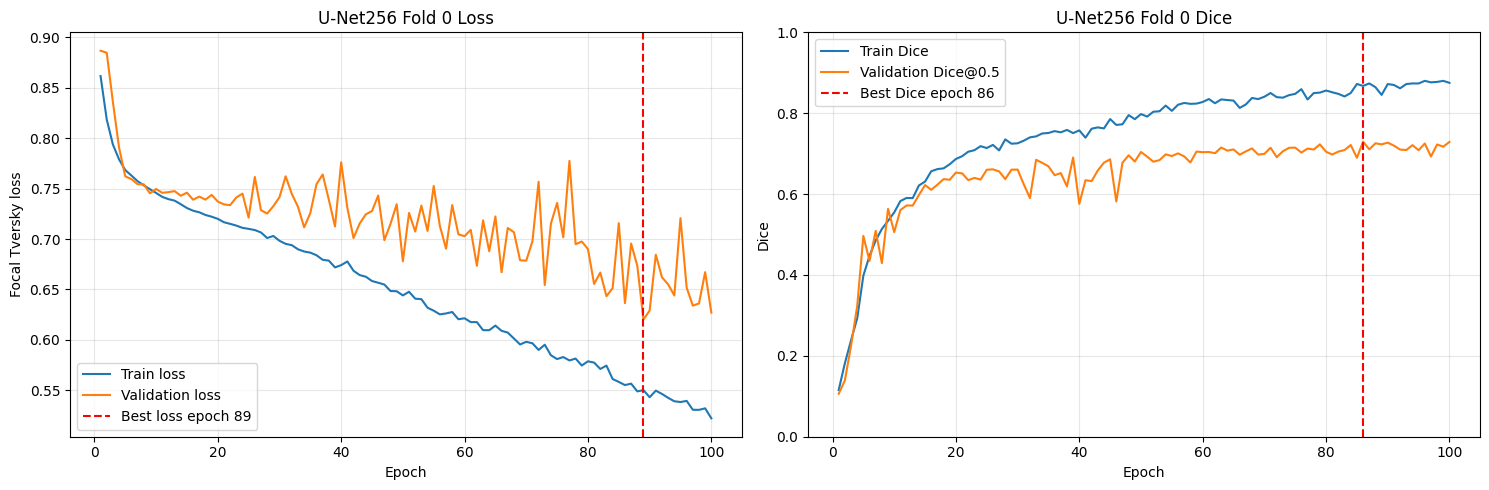

Loss 기준 epoch: 89
Dice 기준 epoch: 86
Checkpoint epoch: 89
저장된 validation loss: 0.6201374023048966
Validation prediction shape: (27, 256, 256)
Probability range: 0.006051901262253523 1.0
재계산 validation loss: 0.6201374023048966
Checkpoint loss 재현 오차: 0.0
✅ Best-loss checkpoint 재현 완료

=== Threshold 0.5 공식 결과 ===


,threshold,pooled_dice,pooled_iou,pooled_precision,pooled_recall,pooled_specificity,pooled_accuracy,predicted_vessel_rate,target_vessel_rate,macro_mean_dice,macro_median_dice,macro_std_dice,empty_prediction_count
40,0.5,0.722948,0.566107,0.641981,0.827284,0.972586,0.964437,0.072276,0.056087,0.719187,0.731276,0.066471,0.0



=== 진단용 최고 threshold ===


,threshold,pooled_dice,pooled_iou,pooled_precision,pooled_recall,pooled_specificity,pooled_accuracy,predicted_vessel_rate,target_vessel_rate,macro_mean_dice,macro_median_dice,macro_std_dice,empty_prediction_count
80,0.9,0.732134,0.577453,0.693004,0.775946,0.979575,0.968154,0.0628,0.056087,0.727991,0.739721,0.070605,0.0


Threshold 이동: 0.4

=== 이미지별 Dice 분포 ===
count    27.000000
mean      0.719187
std       0.066471
min       0.507356
25%       0.698159
50%       0.731276
75%       0.756285
max       0.806199
Name: dice, dtype: float64

=== 성능이 낮은 5개 영상 ===


,array_index,sample_id,checkpoint_epoch,threshold,dice,iou,precision,recall,specificity,accuracy,target_vessel_rate,prediction_vessel_rate,empty_prediction
2,2,11,89,0.5,0.507356,0.339904,0.382228,0.754279,0.949052,0.941238,0.040115,0.079163,0
10,10,39,89,0.5,0.557306,0.386295,0.411887,0.861441,0.950690,0.947250,0.038544,0.080612,0
8,8,30,89,0.5,0.674326,0.508667,0.625995,0.730744,0.978968,0.967560,0.045959,0.053650,0
0,0,8,89,0.5,0.677887,0.512730,0.647129,0.711715,0.981018,0.968460,0.046631,0.051285,0
16,16,70,89,0.5,0.687653,0.523987,0.918044,0.549700,0.993969,0.945343,0.109451,0.065536,0


Macro mean Dice 95% CI: 0.6924929088771145 0.7418133841051998

U-Net128 Fold0 pooled Dice: 0.7321679804195036
U-Net256 Fold0 pooled Dice: 0.7229476872683208
U-Net256 - U-Net128: -0.009220293151182779
※ 해상도별 resized GT에서 계산된 Pilot 참고 비교이며, 최종 결론은 5-Fold OOF paired 비교로 결정합니다.

=== Fold 0 Pilot 평가 Gate ===


,check,observed,expected,status
0,best_checkpoint_exists,1.000000,1,PASS
1,checkpoint_epoch,89.000000,89,PASS
2,validation_loss_reproduction,0.000000,< 1e-5,PASS
3,nonfinite_probability_count,0.000000,0,PASS
4,pooled_dice_at_0_5,0.722948,>= 0.70,PASS
5,macro_median_dice_at_0_5,0.731276,>= 0.60,PASS
6,empty_prediction_count,0.000000,0,PASS
7,diagnostic_threshold_shift,0.400000,<= 0.20 (diagnostic),WARNING



✅ U-Net256 Fold 0 공식 평가 완료
고정 threshold: 0.5
Pooled Dice: 0.7229476872683208
Diagnostic threshold: 0.9

저장 완료:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/06_fold0_training_curves.png
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/07_fold0_threshold_audit.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/08_fold0_per_image_metrics.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/09_fold0_validation_gate.csv
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/10_fold0_validation_predictions.npz
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/11_fold0_overall_metrics.csv


In [ ]:
#@title 8. U-Net256 Fold 0 Best-loss 공식 평가

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PILOT_DIR = (
    UNET256_DIR
    / "fold0_pilot"
)

BEST_LOSS_PATH = (
    PILOT_DIR
    / "01_best_validation_loss.pt"
)

HISTORY_PATH = (
    PILOT_DIR
    / "04_training_history.csv"
)

assert BEST_LOSS_PATH.exists()
assert HISTORY_PATH.exists()

# --------------------------------------------------
# 1. 학습 history 및 curve
# --------------------------------------------------

history_df = pd.read_csv(HISTORY_PATH)

required_history_columns = {
    "epoch",
    "train_loss",
    "train_dice_at_0_5",
    "validation_loss",
    "validation_dice_at_0_5",
}

assert required_history_columns.issubset(
    history_df.columns
)

best_loss_history_row = history_df.loc[
    history_df[
        "validation_loss"
    ].idxmin()
]

best_dice_history_row = history_df.loc[
    history_df[
        "validation_dice_at_0_5"
    ].idxmax()
]

best_loss_epoch = int(
    best_loss_history_row["epoch"]
)
best_dice_epoch = int(
    best_dice_history_row["epoch"]
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train loss",
)
axes[0].plot(
    history_df["epoch"],
    history_df["validation_loss"],
    label="Validation loss",
)
axes[0].axvline(
    best_loss_epoch,
    color="red",
    linestyle="--",
    label=f"Best loss epoch {best_loss_epoch}",
)
axes[0].set_title("U-Net256 Fold 0 Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Focal Tversky loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    history_df["epoch"],
    history_df["train_dice_at_0_5"],
    label="Train Dice",
)
axes[1].plot(
    history_df["epoch"],
    history_df[
        "validation_dice_at_0_5"
    ],
    label="Validation Dice@0.5",
)
axes[1].axvline(
    best_dice_epoch,
    color="red",
    linestyle="--",
    label=f"Best Dice epoch {best_dice_epoch}",
)
axes[1].set_title("U-Net256 Fold 0 Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

CURVE_PATH = (
    PILOT_DIR
    / "06_fold0_training_curves.png"
)

plt.savefig(
    CURVE_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("Loss 기준 epoch:", best_loss_epoch)
print("Dice 기준 epoch:", best_dice_epoch)

# --------------------------------------------------
# 2. Best-loss checkpoint 로드
# --------------------------------------------------

checkpoint = torch.load(
    BEST_LOSS_PATH,
    map_location=DEVICE,
    weights_only=False,
)

evaluation_model = UNet().to(DEVICE)

evaluation_model.load_state_dict(
    checkpoint["model_state_dict"]
)

evaluation_model.eval()

evaluation_criterion = FocalTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=0.75,
)

print(
    "Checkpoint epoch:",
    checkpoint["epoch"],
)
print(
    "저장된 validation loss:",
    checkpoint["validation_loss"],
)

assert int(checkpoint["epoch"]) == 89

# --------------------------------------------------
# 3. Validation 예측 수집
# --------------------------------------------------

probability_list = []
target_list = []
image_list = []
sample_id_list = []

validation_loss_sum = 0.0
validation_sample_count = 0

with torch.no_grad():
    for batch in pilot_val_loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        logits = evaluation_model(images)
        loss = evaluation_criterion(
            logits,
            masks,
        )

        batch_size = images.size(0)

        validation_loss_sum += (
            float(loss.detach().cpu())
            * batch_size
        )
        validation_sample_count += (
            batch_size
        )

        probabilities = torch.sigmoid(
            logits
        )

        probability_list.append(
            probabilities[:, 0]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        target_list.append(
            masks[:, 0]
            .detach()
            .cpu()
            .numpy()
            .astype(np.uint8)
        )

        image_list.append(
            images[:, 0]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        batch_ids = batch["sample_id"]

        if torch.is_tensor(batch_ids):
            batch_ids = (
                batch_ids.cpu().numpy().tolist()
            )
        else:
            batch_ids = list(batch_ids)

        sample_id_list.extend(batch_ids)

validation_probabilities = np.concatenate(
    probability_list,
    axis=0,
)

validation_targets = np.concatenate(
    target_list,
    axis=0,
)

validation_images = np.concatenate(
    image_list,
    axis=0,
)

validation_sample_ids = np.asarray(
    sample_id_list
)

recomputed_validation_loss = (
    validation_loss_sum
    / validation_sample_count
)

print(
    "Validation prediction shape:",
    validation_probabilities.shape,
)
print(
    "Probability range:",
    float(validation_probabilities.min()),
    float(validation_probabilities.max()),
)
print(
    "재계산 validation loss:",
    recomputed_validation_loss,
)

assert validation_probabilities.shape == (
    27, 256, 256
)
assert validation_targets.shape == (
    27, 256, 256
)
assert np.isfinite(
    validation_probabilities
).all()

loss_reproduction_difference = abs(
    recomputed_validation_loss
    - float(checkpoint["validation_loss"])
)

print(
    "Checkpoint loss 재현 오차:",
    loss_reproduction_difference,
)

assert loss_reproduction_difference < 1e-5

print("✅ Best-loss checkpoint 재현 완료")

# --------------------------------------------------
# 4. Metric 함수
# --------------------------------------------------

def calculate_binary_metrics(
    prediction,
    target,
    epsilon=1e-8,
):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    tp = np.logical_and(
        prediction,
        target,
    ).sum()

    fp = np.logical_and(
        prediction,
        ~target,
    ).sum()

    fn = np.logical_and(
        ~prediction,
        target,
    ).sum()

    tn = np.logical_and(
        ~prediction,
        ~target,
    ).sum()

    dice = (
        2 * tp + epsilon
    ) / (
        2 * tp + fp + fn + epsilon
    )

    iou = (
        tp + epsilon
    ) / (
        tp + fp + fn + epsilon
    )

    precision = (
        tp + epsilon
    ) / (
        tp + fp + epsilon
    )

    recall = (
        tp + epsilon
    ) / (
        tp + fn + epsilon
    )

    specificity = (
        tn + epsilon
    ) / (
        tn + fp + epsilon
    )

    accuracy = (
        tp + tn + epsilon
    ) / (
        tp + tn + fp + fn + epsilon
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "accuracy": float(accuracy),
    }


def evaluate_threshold(
    probabilities,
    targets,
    threshold,
):
    predictions = (
        probabilities >= threshold
    )

    pooled = calculate_binary_metrics(
        predictions,
        targets,
    )

    per_image_metrics = [
        calculate_binary_metrics(
            predictions[index],
            targets[index],
        )
        for index in range(len(targets))
    ]

    per_image_dice = np.asarray(
        [
            row["dice"]
            for row in per_image_metrics
        ]
    )

    return {
        "threshold": float(threshold),
        "pooled_dice": pooled["dice"],
        "pooled_iou": pooled["iou"],
        "pooled_precision": (
            pooled["precision"]
        ),
        "pooled_recall": pooled["recall"],
        "pooled_specificity": (
            pooled["specificity"]
        ),
        "pooled_accuracy": (
            pooled["accuracy"]
        ),
        "predicted_vessel_rate": float(
            predictions.mean()
        ),
        "target_vessel_rate": float(
            targets.mean()
        ),
        "macro_mean_dice": float(
            per_image_dice.mean()
        ),
        "macro_median_dice": float(
            np.median(per_image_dice)
        ),
        "macro_std_dice": float(
            per_image_dice.std(ddof=1)
        ),
        "empty_prediction_count": int(
            (
                predictions.sum(
                    axis=(1, 2)
                ) == 0
            ).sum()
        ),
    }

# --------------------------------------------------
# 5. 공식 threshold 0.5 및 진단 threshold
# --------------------------------------------------

threshold_values = np.round(
    np.arange(0.10, 0.91, 0.01),
    2,
)

threshold_audit_df = pd.DataFrame(
    [
        evaluate_threshold(
            validation_probabilities,
            validation_targets,
            threshold,
        )
        for threshold in threshold_values
    ]
)

official_row = (
    threshold_audit_df.loc[
        np.isclose(
            threshold_audit_df["threshold"],
            0.5,
        )
    ]
    .iloc[0]
)

diagnostic_best_row = (
    threshold_audit_df.loc[
        threshold_audit_df[
            "pooled_dice"
        ].idxmax()
    ]
)

print("\n=== Threshold 0.5 공식 결과 ===")
display(official_row.to_frame().T)

print("\n=== 진단용 최고 threshold ===")
display(
    diagnostic_best_row.to_frame().T
)

print(
    "Threshold 이동:",
    abs(
        diagnostic_best_row["threshold"]
        - 0.5
    ),
)

# --------------------------------------------------
# 6. 이미지별 공식 metric
# --------------------------------------------------

official_predictions = (
    validation_probabilities >= 0.5
)

per_image_rows = []

for index in range(
    len(validation_targets)
):
    metrics = calculate_binary_metrics(
        official_predictions[index],
        validation_targets[index],
    )

    per_image_rows.append(
        {
            "array_index": index,
            "sample_id": (
                validation_sample_ids[index]
            ),
            "checkpoint_epoch": int(
                checkpoint["epoch"]
            ),
            "threshold": 0.5,
            **metrics,
            "target_vessel_rate": float(
                validation_targets[
                    index
                ].mean()
            ),
            "prediction_vessel_rate": float(
                official_predictions[
                    index
                ].mean()
            ),
            "empty_prediction": int(
                official_predictions[
                    index
                ].sum() == 0
            ),
        }
    )

per_image_df = pd.DataFrame(
    per_image_rows
)

print("\n=== 이미지별 Dice 분포 ===")
print(
    per_image_df["dice"].describe()
)

print("\n=== 성능이 낮은 5개 영상 ===")
display(
    per_image_df
    .sort_values("dice")
    .head(5)
)

# --------------------------------------------------
# 7. Macro Dice bootstrap CI
# --------------------------------------------------

rng = np.random.default_rng(SEED)

dice_values = (
    per_image_df["dice"]
    .to_numpy(dtype=np.float64)
)

bootstrap_means = np.empty(5000)

for bootstrap_index in range(5000):
    sampled_dice = rng.choice(
        dice_values,
        size=len(dice_values),
        replace=True,
    )

    bootstrap_means[
        bootstrap_index
    ] = sampled_dice.mean()

macro_ci_lower = float(
    np.quantile(
        bootstrap_means,
        0.025,
    )
)

macro_ci_upper = float(
    np.quantile(
        bootstrap_means,
        0.975,
    )
)

print(
    "Macro mean Dice 95% CI:",
    macro_ci_lower,
    macro_ci_upper,
)

# --------------------------------------------------
# 8. U-Net128 Fold 0 참고 비교
# --------------------------------------------------

UNET128_FOLD0_POOLED_DICE = (
    0.7321679804195036
)

dice_difference_vs_128 = (
    float(official_row["pooled_dice"])
    - UNET128_FOLD0_POOLED_DICE
)

print(
    "\nU-Net128 Fold0 pooled Dice:",
    UNET128_FOLD0_POOLED_DICE,
)
print(
    "U-Net256 Fold0 pooled Dice:",
    float(official_row["pooled_dice"]),
)
print(
    "U-Net256 - U-Net128:",
    dice_difference_vs_128,
)

print(
    "※ 해상도별 resized GT에서 계산된 "
    "Pilot 참고 비교이며, 최종 결론은 "
    "5-Fold OOF paired 비교로 결정합니다."
)

# --------------------------------------------------
# 9. Gate
# --------------------------------------------------

diagnostic_threshold_shift = abs(
    float(diagnostic_best_row["threshold"])
    - 0.5
)

gate_rows = [
    {
        "check": "best_checkpoint_exists",
        "observed": int(
            BEST_LOSS_PATH.exists()
        ),
        "expected": 1,
        "status": "PASS",
    },
    {
        "check": "checkpoint_epoch",
        "observed": int(
            checkpoint["epoch"]
        ),
        "expected": 89,
        "status": (
            "PASS"
            if int(
                checkpoint["epoch"]
            ) == 89
            else "FAIL"
        ),
    },
    {
        "check": "validation_loss_reproduction",
        "observed": (
            loss_reproduction_difference
        ),
        "expected": "< 1e-5",
        "status": (
            "PASS"
            if loss_reproduction_difference
            < 1e-5
            else "FAIL"
        ),
    },
    {
        "check": "nonfinite_probability_count",
        "observed": int(
            (~np.isfinite(
                validation_probabilities
            )).sum()
        ),
        "expected": 0,
        "status": (
            "PASS"
            if np.isfinite(
                validation_probabilities
            ).all()
            else "FAIL"
        ),
    },
    {
        "check": "pooled_dice_at_0_5",
        "observed": float(
            official_row["pooled_dice"]
        ),
        "expected": ">= 0.70",
        "status": (
            "PASS"
            if official_row[
                "pooled_dice"
            ] >= 0.70
            else "FAIL"
        ),
    },
    {
        "check": "macro_median_dice_at_0_5",
        "observed": float(
            official_row[
                "macro_median_dice"
            ]
        ),
        "expected": ">= 0.60",
        "status": (
            "PASS"
            if official_row[
                "macro_median_dice"
            ] >= 0.60
            else "FAIL"
        ),
    },
    {
        "check": "empty_prediction_count",
        "observed": int(
            official_row[
                "empty_prediction_count"
            ]
        ),
        "expected": 0,
        "status": (
            "PASS"
            if official_row[
                "empty_prediction_count"
            ] == 0
            else "FAIL"
        ),
    },
    {
        "check": "diagnostic_threshold_shift",
        "observed": (
            diagnostic_threshold_shift
        ),
        "expected": "<= 0.20 (diagnostic)",
        "status": (
            "PASS"
            if diagnostic_threshold_shift
            <= 0.20
            else "WARNING"
        ),
    },
]

gate_df = pd.DataFrame(gate_rows)

print("\n=== Fold 0 Pilot 평가 Gate ===")
display(gate_df)

assert not (
    gate_df["status"] == "FAIL"
).any(), (
    "❌ U-Net256 Fold 0 평가 Gate 실패"
)

# --------------------------------------------------
# 10. 저장
# --------------------------------------------------

THRESHOLD_PATH = (
    PILOT_DIR
    / "07_fold0_threshold_audit.csv"
)

PER_IMAGE_PATH = (
    PILOT_DIR
    / "08_fold0_per_image_metrics.csv"
)

GATE_PATH = (
    PILOT_DIR
    / "09_fold0_validation_gate.csv"
)

PREDICTION_PATH = (
    PILOT_DIR
    / "10_fold0_validation_predictions.npz"
)

OVERALL_PATH = (
    PILOT_DIR
    / "11_fold0_overall_metrics.csv"
)

threshold_audit_df.to_csv(
    THRESHOLD_PATH,
    index=False,
    encoding="utf-8-sig",
)

per_image_df.to_csv(
    PER_IMAGE_PATH,
    index=False,
    encoding="utf-8-sig",
)

gate_df.to_csv(
    GATE_PATH,
    index=False,
    encoding="utf-8-sig",
)

overall_df = pd.DataFrame(
    [
        {
            **official_row.to_dict(),
            "checkpoint_epoch": int(
                checkpoint["epoch"]
            ),
            "validation_loss": (
                recomputed_validation_loss
            ),
            "macro_mean_dice_ci_lower": (
                macro_ci_lower
            ),
            "macro_mean_dice_ci_upper": (
                macro_ci_upper
            ),
            "unet128_fold0_pooled_dice": (
                UNET128_FOLD0_POOLED_DICE
            ),
            "dice_difference_vs_unet128": (
                dice_difference_vs_128
            ),
        }
    ]
)

overall_df.to_csv(
    OVERALL_PATH,
    index=False,
    encoding="utf-8-sig",
)

np.savez_compressed(
    PREDICTION_PATH,
    sample_ids=validation_sample_ids,
    images_uint8=np.clip(
        validation_images * 255.0,
        0,
        255,
    ).round().astype(np.uint8),
    masks_uint8=validation_targets.astype(
        np.uint8
    ),
    probabilities_float16=(
        validation_probabilities.astype(
            np.float16
        )
    ),
    checkpoint_epoch=np.asarray(
        [checkpoint["epoch"]],
        dtype=np.int64,
    ),
)

print("\n✅ U-Net256 Fold 0 공식 평가 완료")
print("고정 threshold: 0.5")
print(
    "Pooled Dice:",
    float(official_row["pooled_dice"]),
)
print(
    "Diagnostic threshold:",
    float(
        diagnostic_best_row["threshold"]
    ),
)
print("\n저장 완료:")
print(CURVE_PATH)
print(THRESHOLD_PATH)
print(PER_IMAGE_PATH)
print(GATE_PATH)
print(PREDICTION_PATH)
print(OVERALL_PATH)

/tmp/ipykernel_1297/2125670453.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


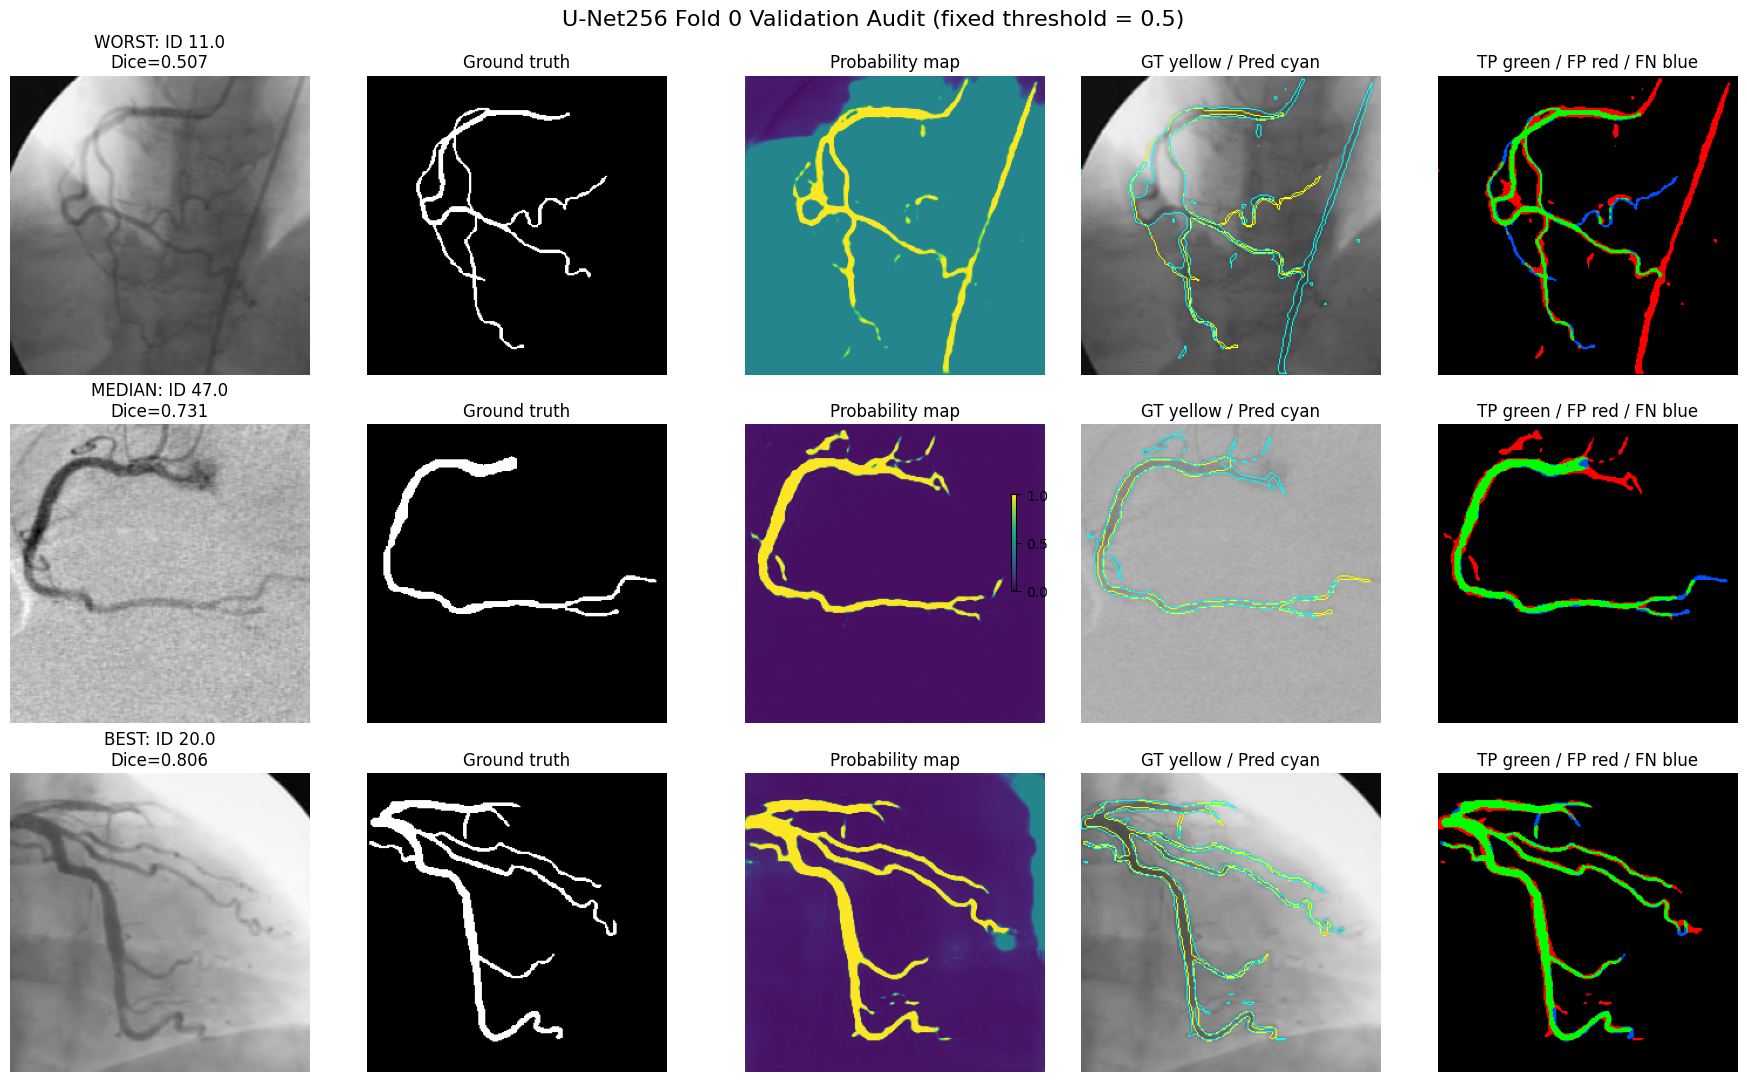

✅ Fold 0 시각 검증 저장 완료
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/fold0_pilot/12_fold0_prediction_overlay.png


In [ ]:
#@title 9. U-Net256 Fold 0 worst/median/best 시각 검증

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PILOT_DIR = (
    UNET256_DIR
    / "fold0_pilot"
)

PREDICTION_PATH = (
    PILOT_DIR
    / "10_fold0_validation_predictions.npz"
)

PER_IMAGE_PATH = (
    PILOT_DIR
    / "08_fold0_per_image_metrics.csv"
)

assert PREDICTION_PATH.exists()
assert PER_IMAGE_PATH.exists()

prediction_data = np.load(
    PREDICTION_PATH,
    allow_pickle=True,
)

images = (
    prediction_data["images_uint8"]
    .astype(np.uint8)
)

targets = (
    prediction_data["masks_uint8"]
    > 0
)

probabilities = (
    prediction_data[
        "probabilities_float16"
    ]
    .astype(np.float32)
)

sample_ids = prediction_data["sample_ids"]

per_image_df = pd.read_csv(
    PER_IMAGE_PATH
)

assert len(images) == 27
assert len(per_image_df) == 27

sorted_metrics_df = (
    per_image_df
    .sort_values("dice")
    .reset_index(drop=True)
)

selected_rows = [
    ("WORST", sorted_metrics_df.iloc[0]),
    (
        "MEDIAN",
        sorted_metrics_df.iloc[
            len(sorted_metrics_df) // 2
        ],
    ),
    ("BEST", sorted_metrics_df.iloc[-1]),
]

fig, axes = plt.subplots(
    3,
    5,
    figsize=(18, 11),
)

for row_index, (
    category,
    metric_row,
) in enumerate(selected_rows):
    array_index = int(
        metric_row["array_index"]
    )

    image = images[array_index]
    target = targets[array_index]
    probability = probabilities[
        array_index
    ]

    prediction = probability >= 0.5

    tp = np.logical_and(
        prediction,
        target,
    )
    fp = np.logical_and(
        prediction,
        ~target,
    )
    fn = np.logical_and(
        ~prediction,
        target,
    )

    contour_overlay = cv2.cvtColor(
        image,
        cv2.COLOR_GRAY2RGB,
    )

    target_contours, _ = (
        cv2.findContours(
            target.astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE,
        )
    )

    prediction_contours, _ = (
        cv2.findContours(
            prediction.astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE,
        )
    )

    cv2.drawContours(
        contour_overlay,
        target_contours,
        -1,
        (255, 255, 0),
        1,
    )
    cv2.drawContours(
        contour_overlay,
        prediction_contours,
        -1,
        (0, 255, 255),
        1,
    )

    error_map = np.zeros(
        (*target.shape, 3),
        dtype=np.uint8,
    )
    error_map[tp] = [0, 255, 0]
    error_map[fp] = [255, 0, 0]
    error_map[fn] = [0, 80, 255]

    axes[row_index, 0].imshow(
        image,
        cmap="gray",
    )
    axes[row_index, 0].set_title(
        f"{category}: ID "
        f"{metric_row['sample_id']}\n"
        f"Dice={metric_row['dice']:.3f}"
    )

    axes[row_index, 1].imshow(
        target,
        cmap="gray",
    )
    axes[row_index, 1].set_title(
        "Ground truth"
    )

    probability_plot = (
        axes[row_index, 2].imshow(
            probability,
            cmap="viridis",
            vmin=0,
            vmax=1,
        )
    )
    axes[row_index, 2].set_title(
        "Probability map"
    )

    axes[row_index, 3].imshow(
        contour_overlay,
    )
    axes[row_index, 3].set_title(
        "GT yellow / Pred cyan"
    )

    axes[row_index, 4].imshow(
        error_map,
    )
    axes[row_index, 4].set_title(
        "TP green / FP red / FN blue"
    )

    for axis in axes[row_index]:
        axis.axis("off")

fig.colorbar(
    probability_plot,
    ax=axes[:, 2],
    fraction=0.02,
    pad=0.02,
)

plt.suptitle(
    "U-Net256 Fold 0 Validation Audit "
    "(fixed threshold = 0.5)",
    fontsize=16,
)
plt.tight_layout()

OVERLAY_PATH = (
    PILOT_DIR
    / "12_fold0_prediction_overlay.png"
)

plt.savefig(
    OVERLAY_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("✅ Fold 0 시각 검증 저장 완료")
print(OVERLAY_PATH)

In [ ]:
#@title 10. U-Net256 Fold 1–4 학습 — Resume 지원

import gc
import json
import shutil
import time
from datetime import datetime

required_variables = [
    "dca1_cv_manifest_df",
    "DCA1SegmentationDataset",
    "UNet",
    "FocalTverskyLoss",
    "IMAGE_PATH_COLUMN",
    "MASK_PATH_COLUMN",
    "SAMPLE_ID_COLUMN",
    "FOLD_COLUMN",
    "DEVICE",
    "UNET256_DIR",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

assert not missing_variables, (
    "복구가 필요한 변수: "
    f"{missing_variables}"
)

FULL_5FOLD_DIR = (
    UNET256_DIR
    / "full_5fold"
)
FULL_5FOLD_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MAX_EPOCHS = 100
PATIENCE = 15
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
CHECKPOINT_INTERVAL = 5

# 완료된 Fold를 강제로 다시 학습하려면 True
FORCE_RESTART = False

def pooled_dice_from_counts(
    tp,
    fp,
    fn,
    epsilon=1e-8,
):
    return float(
        (2 * tp + epsilon)
        / (2 * tp + fp + fn + epsilon)
    )


def run_train_epoch(
    model,
    loader,
    optimizer,
    criterion,
):
    model.train()

    loss_sum = 0.0
    sample_count = 0
    tp = fp = fn = 0.0

    for batch in loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)
        loss = criterion(logits, masks)

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite train loss"
            )

        loss.backward()

        if not all(
            parameter.grad is None
            or torch.isfinite(
                parameter.grad
            ).all().item()
            for parameter in model.parameters()
        ):
            raise RuntimeError(
                "Non-finite gradient"
            )

        optimizer.step()

        current_batch_size = images.size(0)

        loss_sum += (
            float(loss.detach().cpu())
            * current_batch_size
        )
        sample_count += current_batch_size

        with torch.no_grad():
            prediction = (
                torch.sigmoid(logits)
                >= 0.5
            )
            target = masks >= 0.5

            tp += float(
                torch.logical_and(
                    prediction,
                    target,
                ).sum().cpu()
            )
            fp += float(
                torch.logical_and(
                    prediction,
                    ~target,
                ).sum().cpu()
            )
            fn += float(
                torch.logical_and(
                    ~prediction,
                    target,
                ).sum().cpu()
            )

    return {
        "loss": loss_sum / sample_count,
        "dice": pooled_dice_from_counts(
            tp, fp, fn
        ),
    }


@torch.no_grad()
def run_validation_epoch(
    model,
    loader,
    criterion,
):
    model.eval()

    loss_sum = 0.0
    sample_count = 0
    tp = fp = fn = 0.0

    for batch in loader:
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        masks = batch["mask"].to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(images)
        loss = criterion(logits, masks)

        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite validation loss"
            )

        current_batch_size = images.size(0)

        loss_sum += (
            float(loss.detach().cpu())
            * current_batch_size
        )
        sample_count += current_batch_size

        prediction = (
            torch.sigmoid(logits) >= 0.5
        )
        target = masks >= 0.5

        tp += float(
            torch.logical_and(
                prediction,
                target,
            ).sum().cpu()
        )
        fp += float(
            torch.logical_and(
                prediction,
                ~target,
            ).sum().cpu()
        )
        fn += float(
            torch.logical_and(
                ~prediction,
                target,
            ).sum().cpu()
        )

    return {
        "loss": loss_sum / sample_count,
        "dice": pooled_dice_from_counts(
            tp, fp, fn
        ),
    }


def save_model_checkpoint(
    path,
    model,
    fold,
    epoch,
    validation_loss,
    validation_dice,
    selection_metric,
):
    torch.save(
        {
            "fold": fold,
            "epoch": epoch,
            "input_resolution": 256,
            "model_state_dict": (
                model.state_dict()
            ),
            "validation_loss": (
                validation_loss
            ),
            "validation_dice": (
                validation_dice
            ),
            "selection_metric": (
                selection_metric
            ),
            "parameter_count": 7_762_465,
            "seed": SEED,
        },
        path,
    )


fold_summary_rows = []

# Fold 0은 완료된 Pilot checkpoint를 참조
fold0_reference = {
    "fold": 0,
    "source": "fold0_pilot",
    "best_loss_checkpoint": str(
        UNET256_DIR
        / "fold0_pilot"
        / "01_best_validation_loss.pt"
    ),
    "status": "REUSED_COMPLETED_PILOT",
}

with open(
    FULL_5FOLD_DIR
    / "00_fold0_reference.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        fold0_reference,
        file,
        ensure_ascii=False,
        indent=2,
    )

fold0_summary_path = (
    UNET256_DIR
    / "fold0_pilot"
    / "05_training_summary.csv"
)

fold0_summary_df = pd.read_csv(
    fold0_summary_path
)

fold_summary_rows.append(
    {
        "fold": 0,
        "train_samples": 107,
        "validation_samples": 27,
        "best_validation_loss": float(
            fold0_summary_df.iloc[0][
                "best_validation_loss"
            ]
        ),
        "best_validation_loss_epoch": int(
            fold0_summary_df.iloc[0][
                "best_validation_loss_epoch"
            ]
        ),
        "best_validation_dice": float(
            fold0_summary_df.iloc[0][
                "best_validation_dice"
            ]
        ),
        "best_validation_dice_epoch": int(
            fold0_summary_df.iloc[0][
                "best_validation_dice_epoch"
            ]
        ),
        "status": "REUSED_COMPLETED_PILOT",
    }
)

for fold in [1, 2, 3, 4]:
    print("\n" + "=" * 70)
    print(f"Fold {fold} 시작")
    print("=" * 70)

    fold_dir = (
        FULL_5FOLD_DIR
        / f"fold_{fold}"
    )
    fold_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    best_loss_path = (
        fold_dir
        / "01_best_validation_loss.pt"
    )
    best_dice_path = (
        fold_dir
        / "02_best_validation_dice.pt"
    )
    resume_path = (
        fold_dir
        / "03_resume_checkpoint.pt"
    )
    history_path = (
        fold_dir
        / "04_training_history.csv"
    )
    summary_path = (
        fold_dir
        / "05_training_summary.csv"
    )

    # 이미 완료된 Fold는 재학습하지 않음
    if (
        summary_path.exists()
        and best_loss_path.exists()
        and not FORCE_RESTART
    ):
        existing_summary = pd.read_csv(
            summary_path
        )

        if (
            existing_summary.iloc[0][
                "status"
            ] == "TRAINING_COMPLETED"
        ):
            print(
                f"Fold {fold} 완료 결과 재사용"
            )

            fold_summary_rows.append(
                existing_summary.iloc[
                    0
                ].to_dict()
            )
            continue

    train_df = (
        dca1_cv_manifest_df.loc[
            dca1_cv_manifest_df[
                FOLD_COLUMN
            ] != fold
        ]
        .reset_index(drop=True)
    )

    validation_df = (
        dca1_cv_manifest_df.loc[
            dca1_cv_manifest_df[
                FOLD_COLUMN
            ] == fold
        ]
        .reset_index(drop=True)
    )

    train_dataset = (
        DCA1SegmentationDataset(
            train_df,
            IMAGE_PATH_COLUMN,
            MASK_PATH_COLUMN,
            SAMPLE_ID_COLUMN,
            output_size=256,
        )
    )

    validation_dataset = (
        DCA1SegmentationDataset(
            validation_df,
            IMAGE_PATH_COLUMN,
            MASK_PATH_COLUMN,
            SAMPLE_ID_COLUMN,
            output_size=256,
        )
    )

    train_generator = torch.Generator()
    train_generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        generator=train_generator,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = UNet().to(DEVICE)

    assert sum(
        parameter.numel()
        for parameter in model.parameters()
    ) == 7_762_465

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

    criterion = FocalTverskyLoss(
        alpha=0.3,
        beta=0.7,
        gamma=0.75,
    )

    start_epoch = 1
    best_loss = float("inf")
    best_loss_epoch = -1
    best_dice = -float("inf")
    best_dice_epoch = -1
    epochs_without_improvement = 0
    history_rows = []

    if (
        resume_path.exists()
        and not FORCE_RESTART
    ):
        resume_checkpoint = torch.load(
            resume_path,
            map_location=DEVICE,
            weights_only=False,
        )

        model.load_state_dict(
            resume_checkpoint[
                "model_state_dict"
            ]
        )
        optimizer.load_state_dict(
            resume_checkpoint[
                "optimizer_state_dict"
            ]
        )

        start_epoch = (
            int(
                resume_checkpoint["epoch"]
            ) + 1
        )
        best_loss = float(
            resume_checkpoint["best_loss"]
        )
        best_loss_epoch = int(
            resume_checkpoint[
                "best_loss_epoch"
            ]
        )
        best_dice = float(
            resume_checkpoint["best_dice"]
        )
        best_dice_epoch = int(
            resume_checkpoint[
                "best_dice_epoch"
            ]
        )
        epochs_without_improvement = int(
            resume_checkpoint[
                "epochs_without_improvement"
            ]
        )
        history_rows = resume_checkpoint[
            "history_rows"
        ]

        train_generator.set_state(
            resume_checkpoint[
                "train_generator_state"
            ]
        )

        print(
            f"Fold {fold}: epoch "
            f"{start_epoch}부터 resume"
        )

    local_best_loss_path = Path(
        f"/content/unet256_fold{fold}"
        "_best_loss.pt"
    )
    local_best_dice_path = Path(
        f"/content/unet256_fold{fold}"
        "_best_dice.pt"
    )

    training_start = time.time()
    stopped_early = False
    last_completed_epoch = (
        start_epoch - 1
    )

    for epoch in range(
        start_epoch,
        MAX_EPOCHS + 1,
    ):
        epoch_start = time.time()

        train_result = run_train_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
        )

        validation_result = (
            run_validation_epoch(
                model,
                validation_loader,
                criterion,
            )
        )

        epoch_seconds = (
            time.time() - epoch_start
        )

        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": (
                    train_result["loss"]
                ),
                "train_dice_at_0_5": (
                    train_result["dice"]
                ),
                "validation_loss": (
                    validation_result["loss"]
                ),
                "validation_dice_at_0_5": (
                    validation_result["dice"]
                ),
                "epoch_seconds": (
                    epoch_seconds
                ),
            }
        )

        if (
            validation_result["loss"]
            < best_loss
        ):
            best_loss = (
                validation_result["loss"]
            )
            best_loss_epoch = epoch
            epochs_without_improvement = 0

            save_model_checkpoint(
                local_best_loss_path,
                model,
                fold,
                epoch,
                validation_result["loss"],
                validation_result["dice"],
                "minimum_validation_loss",
            )
        else:
            epochs_without_improvement += 1

        if (
            validation_result["dice"]
            > best_dice
        ):
            best_dice = (
                validation_result["dice"]
            )
            best_dice_epoch = epoch

            save_model_checkpoint(
                local_best_dice_path,
                model,
                fold,
                epoch,
                validation_result["loss"],
                validation_result["dice"],
                "maximum_validation_dice_at_0.5",
            )

        pd.DataFrame(
            history_rows
        ).to_csv(
            history_path,
            index=False,
            encoding="utf-8-sig",
        )

        should_checkpoint = (
            epoch % CHECKPOINT_INTERVAL
            == 0
            or epoch == MAX_EPOCHS
            or epochs_without_improvement
            >= PATIENCE
        )

        if should_checkpoint:
            if local_best_loss_path.exists():
                shutil.copy2(
                    local_best_loss_path,
                    best_loss_path,
                )

            if local_best_dice_path.exists():
                shutil.copy2(
                    local_best_dice_path,
                    best_dice_path,
                )

            torch.save(
                {
                    "fold": fold,
                    "epoch": epoch,
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "optimizer_state_dict": (
                        optimizer.state_dict()
                    ),
                    "best_loss": best_loss,
                    "best_loss_epoch": (
                        best_loss_epoch
                    ),
                    "best_dice": best_dice,
                    "best_dice_epoch": (
                        best_dice_epoch
                    ),
                    "epochs_without_improvement": (
                        epochs_without_improvement
                    ),
                    "history_rows": (
                        history_rows
                    ),
                    "train_generator_state": (
                        train_generator.get_state()
                    ),
                },
                resume_path,
            )

        print(
            f"Fold {fold} | "
            f"Epoch {epoch:03d}/100 | "
            f"train loss="
            f"{train_result['loss']:.6f} "
            f"dice={train_result['dice']:.4f} | "
            f"val loss="
            f"{validation_result['loss']:.6f} "
            f"dice="
            f"{validation_result['dice']:.4f} | "
            f"best loss ep={best_loss_epoch} "
            f"best dice ep={best_dice_epoch} | "
            f"{epoch_seconds:.1f}s"
        )

        last_completed_epoch = epoch

        if (
            epochs_without_improvement
            >= PATIENCE
        ):
            stopped_early = True
            print(
                f"Fold {fold} early stopping"
            )
            break

    if local_best_loss_path.exists():
        shutil.copy2(
            local_best_loss_path,
            best_loss_path,
        )

    if local_best_dice_path.exists():
        shutil.copy2(
            local_best_dice_path,
            best_dice_path,
        )

    fold_summary = {
        "fold": fold,
        "train_samples": len(
            train_dataset
        ),
        "validation_samples": len(
            validation_dataset
        ),
        "last_completed_epoch": (
            last_completed_epoch
        ),
        "stopped_early": stopped_early,
        "best_validation_loss": (
            best_loss
        ),
        "best_validation_loss_epoch": (
            best_loss_epoch
        ),
        "best_validation_dice": (
            best_dice
        ),
        "best_validation_dice_epoch": (
            best_dice_epoch
        ),
        "training_seconds": (
            time.time() - training_start
        ),
        "status": "TRAINING_COMPLETED",
    }

    pd.DataFrame(
        [fold_summary]
    ).to_csv(
        summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    fold_summary_rows.append(
        fold_summary
    )

    del model
    del optimizer
    del criterion
    del train_loader
    del validation_loader
    del train_dataset
    del validation_dataset

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# --------------------------------------------------
# 전체 Fold 요약
# --------------------------------------------------

five_fold_summary_df = pd.DataFrame(
    fold_summary_rows
).sort_values("fold")

FIVE_FOLD_SUMMARY_PATH = (
    FULL_5FOLD_DIR
    / "07_unet256_5fold_training_summary.csv"
)

five_fold_summary_df.to_csv(
    FIVE_FOLD_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("\n=== U-Net256 5-Fold 학습 요약 ===")
display(five_fold_summary_df)

assert set(
    five_fold_summary_df["fold"]
) == {0, 1, 2, 3, 4}

assert (
    five_fold_summary_df["status"]
    .isin(
        [
            "TRAINING_COMPLETED",
            "REUSED_COMPLETED_PILOT",
        ]
    )
    .all()
)

print("✅ U-Net256 전체 Fold 학습 완료")
print(FIVE_FOLD_SUMMARY_PATH)


Fold 1 시작
Fold 1 | Epoch 001/100 | train loss=0.861268 dice=0.1149 | val loss=0.888335 dice=0.1043 | best loss ep=1 best dice ep=1 | 3.3s
Fold 1 | Epoch 002/100 | train loss=0.819860 dice=0.1735 | val loss=0.885929 dice=0.1436 | best loss ep=2 best dice ep=2 | 3.0s
Fold 1 | Epoch 003/100 | train loss=0.794941 dice=0.2394 | val loss=0.839074 dice=0.2133 | best loss ep=3 best dice ep=3 | 2.9s
Fold 1 | Epoch 004/100 | train loss=0.779561 dice=0.2912 | val loss=0.789926 dice=0.3256 | best loss ep=4 best dice ep=4 | 2.9s
Fold 1 | Epoch 005/100 | train loss=0.770652 dice=0.3590 | val loss=0.774631 dice=0.3996 | best loss ep=5 best dice ep=5 | 3.0s
Fold 1 | Epoch 006/100 | train loss=0.763681 dice=0.4383 | val loss=0.767425 dice=0.4088 | best loss ep=6 best dice ep=6 | 3.1s
Fold 1 | Epoch 007/100 | train loss=0.757840 dice=0.4723 | val loss=0.764384 dice=0.4428 | best loss ep=7 best dice ep=7 | 2.9s
Fold 1 | Epoch 008/100 | train loss=0.754255 dice=0.4933 | val loss=0.759906 dice=0.4282 | be

,fold,train_samples,validation_samples,best_validation_loss,best_validation_loss_epoch,best_validation_dice,best_validation_dice_epoch,status,last_completed_epoch,stopped_early,training_seconds
0,0,107,27,0.620137,89,0.729756,86,REUSED_COMPLETED_PILOT,NaN,NaN,NaN
1,1,107,27,0.607908,93,0.737812,100,TRAINING_COMPLETED,100.0,False,369.651288
2,2,107,27,0.629865,48,0.731529,59,TRAINING_COMPLETED,63.0,True,236.858558
3,3,107,27,0.642477,50,0.740284,65,TRAINING_COMPLETED,65.0,True,244.302525
4,4,108,26,0.674821,48,0.709556,61,TRAINING_COMPLETED,63.0,True,241.172970


✅ U-Net256 전체 Fold 학습 완료
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/full_5fold/07_unet256_5fold_training_summary.csv


In [ ]:
#@title 11. U-Net256 5-Fold OOF 및 U-Net128 Paired 비교

from pathlib import Path
from scipy.stats import wilcoxon

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

FULL_5FOLD_DIR = (
    UNET256_DIR
    / "full_5fold"
)

OOF_DIR = (
    FULL_5FOLD_DIR
    / "oof_evaluation"
)
OOF_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# --------------------------------------------------
# 1. Checkpoint 경로
# --------------------------------------------------

checkpoint_paths = {
    0: (
        UNET256_DIR
        / "fold0_pilot"
        / "01_best_validation_loss.pt"
    ),
    1: (
        FULL_5FOLD_DIR
        / "fold_1"
        / "01_best_validation_loss.pt"
    ),
    2: (
        FULL_5FOLD_DIR
        / "fold_2"
        / "01_best_validation_loss.pt"
    ),
    3: (
        FULL_5FOLD_DIR
        / "fold_3"
        / "01_best_validation_loss.pt"
    ),
    4: (
        FULL_5FOLD_DIR
        / "fold_4"
        / "01_best_validation_loss.pt"
    ),
}

for fold, path in checkpoint_paths.items():
    assert path.exists(), (
        f"Fold {fold} checkpoint 없음: {path}"
    )

# --------------------------------------------------
# 2. OOF 배열 초기화
# --------------------------------------------------

sample_count = len(
    dca1_cv_manifest_df
)

assert sample_count == 134

oof_probabilities = np.zeros(
    (sample_count, 256, 256),
    dtype=np.float32,
)

oof_targets = np.zeros(
    (sample_count, 256, 256),
    dtype=np.uint8,
)

oof_images = np.zeros(
    (sample_count, 256, 256),
    dtype=np.uint8,
)

oof_sample_ids = np.empty(
    sample_count,
    dtype=np.int64,
)

oof_folds = np.full(
    sample_count,
    -1,
    dtype=np.int64,
)

assignment_count = np.zeros(
    sample_count,
    dtype=np.int64,
)

checkpoint_audit_rows = []

criterion = FocalTverskyLoss(
    alpha=0.3,
    beta=0.7,
    gamma=0.75,
)

# --------------------------------------------------
# 3. 각 Fold best-loss OOF 예측
# --------------------------------------------------

for fold in range(5):
    validation_indices = (
        dca1_cv_manifest_df.index[
            dca1_cv_manifest_df[
                FOLD_COLUMN
            ] == fold
        ]
        .to_numpy()
    )

    validation_df = (
        dca1_cv_manifest_df.loc[
            validation_indices
        ]
        .reset_index(drop=True)
    )

    validation_dataset = (
        DCA1SegmentationDataset(
            validation_df,
            IMAGE_PATH_COLUMN,
            MASK_PATH_COLUMN,
            SAMPLE_ID_COLUMN,
            output_size=256,
        )
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=8,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    checkpoint = torch.load(
        checkpoint_paths[fold],
        map_location=DEVICE,
        weights_only=False,
    )

    assert int(checkpoint["fold"]) == fold

    model = UNet().to(DEVICE)
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
    model.eval()

    fold_probability_list = []
    fold_target_list = []
    fold_image_list = []

    loss_sum = 0.0
    fold_sample_count = 0

    with torch.no_grad():
        for batch in validation_loader:
            images = batch["image"].to(
                DEVICE,
                non_blocking=True,
            )
            masks = batch["mask"].to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(images)
            loss = criterion(logits, masks)

            current_batch_size = (
                images.size(0)
            )

            loss_sum += (
                float(loss.detach().cpu())
                * current_batch_size
            )
            fold_sample_count += (
                current_batch_size
            )

            fold_probability_list.append(
                torch.sigmoid(logits)[:, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            fold_target_list.append(
                masks[:, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.uint8)
            )

            fold_image_list.append(
                images[:, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

    fold_probabilities = np.concatenate(
        fold_probability_list,
        axis=0,
    )
    fold_targets = np.concatenate(
        fold_target_list,
        axis=0,
    )
    fold_images = np.concatenate(
        fold_image_list,
        axis=0,
    )

    assert (
        len(fold_probabilities)
        == len(validation_indices)
    )

    fold_validation_loss = (
        loss_sum / fold_sample_count
    )

    stored_validation_loss = float(
        checkpoint["validation_loss"]
    )

    loss_difference = abs(
        fold_validation_loss
        - stored_validation_loss
    )

    oof_probabilities[
        validation_indices
    ] = fold_probabilities

    oof_targets[
        validation_indices
    ] = fold_targets

    oof_images[
        validation_indices
    ] = np.clip(
        fold_images * 255.0,
        0,
        255,
    ).round().astype(np.uint8)

    oof_sample_ids[
        validation_indices
    ] = (
        validation_df[
            SAMPLE_ID_COLUMN
        ]
        .to_numpy(dtype=np.int64)
    )

    oof_folds[
        validation_indices
    ] = fold

    assignment_count[
        validation_indices
    ] += 1

    checkpoint_audit_rows.append(
        {
            "fold": fold,
            "checkpoint_epoch": int(
                checkpoint["epoch"]
            ),
            "validation_samples": (
                fold_sample_count
            ),
            "stored_validation_loss": (
                stored_validation_loss
            ),
            "recomputed_validation_loss": (
                fold_validation_loss
            ),
            "loss_absolute_difference": (
                loss_difference
            ),
            "probability_finite": int(
                np.isfinite(
                    fold_probabilities
                ).all()
            ),
            "status": (
                "PASS"
                if (
                    loss_difference < 1e-5
                    and np.isfinite(
                        fold_probabilities
                    ).all()
                )
                else "FAIL"
            ),
        }
    )

    print(
        f"Fold {fold}: "
        f"epoch={checkpoint['epoch']}, "
        f"loss={fold_validation_loss:.6f}, "
        f"재현 오차={loss_difference:.2e}"
    )

    del model
    del validation_loader
    del validation_dataset

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

checkpoint_audit_df = pd.DataFrame(
    checkpoint_audit_rows
)

display(checkpoint_audit_df)

assert (
    checkpoint_audit_df["status"]
    == "PASS"
).all()
assert np.all(assignment_count == 1)
assert np.isfinite(
    oof_probabilities
).all()
assert set(oof_folds) == {
    0, 1, 2, 3, 4
}

print("✅ 134장 OOF 예측 수집 완료")

# --------------------------------------------------
# 4. Metric 함수
# --------------------------------------------------

def binary_counts(
    prediction,
    target,
):
    prediction = prediction.astype(bool)
    target = target.astype(bool)

    return {
        "tp": int(
            np.logical_and(
                prediction,
                target,
            ).sum()
        ),
        "fp": int(
            np.logical_and(
                prediction,
                ~target,
            ).sum()
        ),
        "fn": int(
            np.logical_and(
                ~prediction,
                target,
            ).sum()
        ),
        "tn": int(
            np.logical_and(
                ~prediction,
                ~target,
            ).sum()
        ),
    }


def metrics_from_counts(
    tp,
    fp,
    fn,
    tn,
    epsilon=1e-8,
):
    return {
        "dice": (
            2 * tp + epsilon
        ) / (
            2 * tp + fp + fn + epsilon
        ),
        "iou": (
            tp + epsilon
        ) / (
            tp + fp + fn + epsilon
        ),
        "precision": (
            tp + epsilon
        ) / (
            tp + fp + epsilon
        ),
        "recall": (
            tp + epsilon
        ) / (
            tp + fn + epsilon
        ),
        "specificity": (
            tn + epsilon
        ) / (
            tn + fp + epsilon
        ),
        "accuracy": (
            tp + tn + epsilon
        ) / (
            tp + fp + fn + tn + epsilon
        ),
    }


def evaluate_oof_threshold(
    probabilities,
    targets,
    threshold,
):
    predictions = (
        probabilities >= threshold
    )

    total_counts = binary_counts(
        predictions,
        targets,
    )

    pooled = metrics_from_counts(
        **total_counts
    )

    per_image_dice = []

    for index in range(len(targets)):
        counts = binary_counts(
            predictions[index],
            targets[index],
        )
        metrics = metrics_from_counts(
            **counts
        )
        per_image_dice.append(
            metrics["dice"]
        )

    per_image_dice = np.asarray(
        per_image_dice
    )

    return {
        "threshold": float(threshold),
        "pooled_dice": float(
            pooled["dice"]
        ),
        "pooled_iou": float(
            pooled["iou"]
        ),
        "pooled_precision": float(
            pooled["precision"]
        ),
        "pooled_recall": float(
            pooled["recall"]
        ),
        "pooled_specificity": float(
            pooled["specificity"]
        ),
        "pooled_accuracy": float(
            pooled["accuracy"]
        ),
        "predicted_vessel_rate": float(
            predictions.mean()
        ),
        "target_vessel_rate": float(
            targets.mean()
        ),
        "macro_mean_dice": float(
            per_image_dice.mean()
        ),
        "macro_median_dice": float(
            np.median(per_image_dice)
        ),
        "macro_std_dice": float(
            per_image_dice.std(ddof=1)
        ),
        "empty_prediction_count": int(
            (
                predictions.sum(
                    axis=(1, 2)
                ) == 0
            ).sum()
        ),
    }

# --------------------------------------------------
# 5. Fixed threshold 0.5 및 진단 threshold
# --------------------------------------------------

threshold_values = np.round(
    np.arange(0.10, 1.00, 0.01),
    2,
)

threshold_audit_df = pd.DataFrame(
    [
        evaluate_oof_threshold(
            oof_probabilities,
            oof_targets,
            threshold,
        )
        for threshold in tqdm(
            threshold_values,
            desc="OOF threshold 검사",
        )
    ]
)

official_row = (
    threshold_audit_df.loc[
        np.isclose(
            threshold_audit_df["threshold"],
            0.5,
        )
    ]
    .iloc[0]
)

diagnostic_best_row = (
    threshold_audit_df.loc[
        threshold_audit_df[
            "pooled_dice"
        ].idxmax()
    ]
)

print("\n=== U-Net256 공식 OOF @0.5 ===")
display(official_row.to_frame().T)

print("\n=== 진단용 최고 threshold ===")
display(
    diagnostic_best_row.to_frame().T
)

# --------------------------------------------------
# 6. 이미지별 및 Fold별 metric
# --------------------------------------------------

official_predictions = (
    oof_probabilities >= 0.5
)

per_image_rows = []

for index in range(sample_count):
    counts = binary_counts(
        official_predictions[index],
        oof_targets[index],
    )
    metrics = metrics_from_counts(
        **counts
    )

    per_image_rows.append(
        {
            "array_index": index,
            "sample_id": int(
                oof_sample_ids[index]
            ),
            "cv_fold": int(
                oof_folds[index]
            ),
            **counts,
            **metrics,
            "target_vessel_rate": float(
                oof_targets[index].mean()
            ),
            "prediction_vessel_rate": float(
                official_predictions[
                    index
                ].mean()
            ),
            "empty_prediction": int(
                official_predictions[
                    index
                ].sum() == 0
            ),
        }
    )

per_image_df = pd.DataFrame(
    per_image_rows
)

fold_metric_rows = []

for fold in range(5):
    fold_indices = np.where(
        oof_folds == fold
    )[0]

    fold_counts = binary_counts(
        official_predictions[
            fold_indices
        ],
        oof_targets[fold_indices],
    )

    fold_metrics = metrics_from_counts(
        **fold_counts
    )

    fold_metric_rows.append(
        {
            "fold": fold,
            "sample_count": len(
                fold_indices
            ),
            **fold_metrics,
            "macro_mean_dice": float(
                per_image_df.loc[
                    per_image_df[
                        "cv_fold"
                    ] == fold,
                    "dice",
                ].mean()
            ),
        }
    )

fold_metrics_df = pd.DataFrame(
    fold_metric_rows
)

print("\n=== Fold별 공식 metric ===")
display(fold_metrics_df)

print("\n=== 이미지별 Dice 분포 ===")
print(per_image_df["dice"].describe())

# --------------------------------------------------
# 7. Bootstrap CI
# --------------------------------------------------

rng = np.random.default_rng(SEED)

image_counts = per_image_df[
    ["tp", "fp", "fn", "tn"]
].to_numpy(dtype=np.int64)

bootstrap_pooled_dice = np.empty(
    5000,
    dtype=np.float64,
)

bootstrap_macro_dice = np.empty(
    5000,
    dtype=np.float64,
)

per_image_dice_values = (
    per_image_df["dice"]
    .to_numpy(dtype=np.float64)
)

for iteration in range(5000):
    sampled_indices = rng.integers(
        0,
        sample_count,
        size=sample_count,
    )

    sampled_counts = image_counts[
        sampled_indices
    ].sum(axis=0)

    sampled_metrics = metrics_from_counts(
        tp=sampled_counts[0],
        fp=sampled_counts[1],
        fn=sampled_counts[2],
        tn=sampled_counts[3],
    )

    bootstrap_pooled_dice[
        iteration
    ] = sampled_metrics["dice"]

    bootstrap_macro_dice[
        iteration
    ] = per_image_dice_values[
        sampled_indices
    ].mean()

pooled_ci = np.quantile(
    bootstrap_pooled_dice,
    [0.025, 0.975],
)

macro_ci = np.quantile(
    bootstrap_macro_dice,
    [0.025, 0.975],
)

print(
    "Pooled Dice 95% CI:",
    pooled_ci,
)
print(
    "Macro Dice 95% CI:",
    macro_ci,
)

# --------------------------------------------------
# 8. U-Net128 OOF Paired 비교
# --------------------------------------------------

UNET128_OOF_PATH = (
    DCA1_RESULT_DIR
    / "unet128_5fold_raw"
    / "05_unet128_oof_predictions.npz"
)

assert UNET128_OOF_PATH.exists()

unet128_data = np.load(
    UNET128_OOF_PATH,
    allow_pickle=True,
)

unet128_sample_ids = (
    unet128_data["sample_ids"]
    .astype(np.int64)
)

unet128_probabilities = (
    unet128_data[
        "probabilities_float16"
    ]
    .astype(np.float32)
)

unet128_targets = (
    unet128_data["masks_uint8"]
    > 0
)

unet128_id_to_index = {
    int(sample_id): index
    for index, sample_id
    in enumerate(unet128_sample_ids)
}

paired_rows = []

for row in per_image_df.itertuples():
    sample_id = int(row.sample_id)

    assert sample_id in (
        unet128_id_to_index
    )

    unet128_index = (
        unet128_id_to_index[sample_id]
    )

    unet128_prediction = (
        unet128_probabilities[
            unet128_index
        ] >= 0.5
    )

    unet128_counts = binary_counts(
        unet128_prediction,
        unet128_targets[
            unet128_index
        ],
    )

    unet128_metrics = (
        metrics_from_counts(
            **unet128_counts
        )
    )

    delta = (
        row.dice
        - unet128_metrics["dice"]
    )

    paired_rows.append(
        {
            "sample_id": sample_id,
            "cv_fold": int(row.cv_fold),
            "unet128_dice": float(
                unet128_metrics["dice"]
            ),
            "unet256_dice": float(
                row.dice
            ),
            "dice_delta_256_minus_128": (
                float(delta)
            ),
        }
    )

paired_df = pd.DataFrame(
    paired_rows
)

paired_deltas = paired_df[
    "dice_delta_256_minus_128"
].to_numpy()

bootstrap_delta_means = np.empty(
    5000,
    dtype=np.float64,
)

for iteration in range(5000):
    sampled_deltas = rng.choice(
        paired_deltas,
        size=len(paired_deltas),
        replace=True,
    )

    bootstrap_delta_means[
        iteration
    ] = sampled_deltas.mean()

paired_delta_ci = np.quantile(
    bootstrap_delta_means,
    [0.025, 0.975],
)

wilcoxon_result = wilcoxon(
    paired_df["unet256_dice"],
    paired_df["unet128_dice"],
    zero_method="wilcox",
    alternative="two-sided",
)

win_count = int(
    (paired_deltas > 1e-12).sum()
)
loss_count = int(
    (paired_deltas < -1e-12).sum()
)
tie_count = int(
    (
        np.abs(paired_deltas)
        <= 1e-12
    ).sum()
)

print("\n=== U-Net128 vs U-Net256 Paired ===")
print(
    "U-Net128 macro mean Dice:",
    paired_df["unet128_dice"].mean(),
)
print(
    "U-Net256 macro mean Dice:",
    paired_df["unet256_dice"].mean(),
)
print(
    "평균 Dice delta:",
    paired_deltas.mean(),
)
print(
    "Delta 95% CI:",
    paired_delta_ci,
)
print(
    "Win/Tie/Loss:",
    win_count,
    tie_count,
    loss_count,
)
print(
    "Wilcoxon p-value:",
    wilcoxon_result.pvalue,
)

# --------------------------------------------------
# 9. Gate 및 저장
# --------------------------------------------------

threshold_shift = abs(
    float(diagnostic_best_row["threshold"])
    - 0.5
)

gate_df = pd.DataFrame(
    [
        {
            "check": "checkpoint_count",
            "observed": len(
                checkpoint_audit_df
            ),
            "expected": 5,
            "status": "PASS",
        },
        {
            "check": "checkpoint_reproduction_failure",
            "observed": int(
                (
                    checkpoint_audit_df[
                        "status"
                    ] != "PASS"
                ).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if (
                    checkpoint_audit_df[
                        "status"
                    ] == "PASS"
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "oof_assignment_not_one",
            "observed": int(
                (assignment_count != 1).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if np.all(
                    assignment_count == 1
                )
                else "FAIL"
            ),
        },
        {
            "check": "nonfinite_probability_count",
            "observed": int(
                (~np.isfinite(
                    oof_probabilities
                )).sum()
            ),
            "expected": 0,
            "status": (
                "PASS"
                if np.isfinite(
                    oof_probabilities
                ).all()
                else "FAIL"
            ),
        },
        {
            "check": "pooled_dice_at_0_5",
            "observed": float(
                official_row["pooled_dice"]
            ),
            "expected": ">= 0.70",
            "status": (
                "PASS"
                if official_row[
                    "pooled_dice"
                ] >= 0.70
                else "FAIL"
            ),
        },
        {
            "check": "empty_prediction_count",
            "observed": int(
                official_row[
                    "empty_prediction_count"
                ]
            ),
            "expected": 0,
            "status": (
                "PASS"
                if official_row[
                    "empty_prediction_count"
                ] == 0
                else "FAIL"
            ),
        },
        {
            "check": "diagnostic_threshold_shift",
            "observed": threshold_shift,
            "expected": "<= 0.20",
            "status": (
                "PASS"
                if threshold_shift <= 0.20
                else "WARNING"
            ),
        },
    ]
)

display(gate_df)

assert not (
    gate_df["status"] == "FAIL"
).any()

OOF_PREDICTION_PATH = (
    OOF_DIR
    / "08_unet256_oof_predictions.npz"
)

PER_IMAGE_OUTPUT_PATH = (
    OOF_DIR
    / "09_unet256_oof_per_image_metrics.csv"
)

FOLD_METRIC_PATH = (
    OOF_DIR
    / "10_unet256_oof_fold_metrics.csv"
)

THRESHOLD_OUTPUT_PATH = (
    OOF_DIR
    / "11_unet256_oof_threshold_audit.csv"
)

OVERALL_OUTPUT_PATH = (
    OOF_DIR
    / "12_unet256_oof_overall_metrics.csv"
)

PAIRED_OUTPUT_PATH = (
    OOF_DIR
    / "13_unet128_vs_unet256_paired.csv"
)

GATE_OUTPUT_PATH = (
    OOF_DIR
    / "14_unet256_oof_gate.csv"
)

CHECKPOINT_AUDIT_PATH = (
    OOF_DIR
    / "15_checkpoint_reproduction_audit.csv"
)

np.savez_compressed(
    OOF_PREDICTION_PATH,
    sample_ids=oof_sample_ids,
    cv_folds=oof_folds,
    images_uint8=oof_images,
    masks_uint8=oof_targets,
    probabilities_float16=(
        oof_probabilities.astype(
            np.float16
        )
    ),
)

per_image_df.to_csv(
    PER_IMAGE_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

fold_metrics_df.to_csv(
    FOLD_METRIC_PATH,
    index=False,
    encoding="utf-8-sig",
)

threshold_audit_df.to_csv(
    THRESHOLD_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

overall_df = pd.DataFrame(
    [
        {
            **official_row.to_dict(),
            "pooled_dice_ci_lower": (
                pooled_ci[0]
            ),
            "pooled_dice_ci_upper": (
                pooled_ci[1]
            ),
            "macro_dice_ci_lower": (
                macro_ci[0]
            ),
            "macro_dice_ci_upper": (
                macro_ci[1]
            ),
            "diagnostic_best_threshold": (
                diagnostic_best_row[
                    "threshold"
                ]
            ),
            "diagnostic_best_pooled_dice": (
                diagnostic_best_row[
                    "pooled_dice"
                ]
            ),
            "mean_delta_vs_unet128": (
                paired_deltas.mean()
            ),
            "paired_delta_ci_lower": (
                paired_delta_ci[0]
            ),
            "paired_delta_ci_upper": (
                paired_delta_ci[1]
            ),
            "paired_win_count": win_count,
            "paired_tie_count": tie_count,
            "paired_loss_count": loss_count,
            "wilcoxon_p_value": (
                wilcoxon_result.pvalue
            ),
        }
    ]
)

overall_df.to_csv(
    OVERALL_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

paired_df.to_csv(
    PAIRED_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

gate_df.to_csv(
    GATE_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

checkpoint_audit_df.to_csv(
    CHECKPOINT_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("\n✅ U-Net256 5-Fold OOF 평가 완료")
print("공식 threshold: 0.5")
print(
    "공식 pooled Dice:",
    float(official_row["pooled_dice"]),
)
print(
    "Paired mean delta:",
    paired_deltas.mean(),
)
print("\n저장 위치:")
print(OOF_DIR)

Fold 0: epoch=89, loss=0.620137, 재현 오차=0.00e+00
Fold 1: epoch=93, loss=0.607908, 재현 오차=0.00e+00
Fold 2: epoch=48, loss=0.629865, 재현 오차=0.00e+00
Fold 3: epoch=50, loss=0.642477, 재현 오차=0.00e+00
Fold 4: epoch=48, loss=0.674821, 재현 오차=0.00e+00


,fold,checkpoint_epoch,validation_samples,stored_validation_loss,recomputed_validation_loss,loss_absolute_difference,probability_finite,status
0,0,89,27,0.620137,0.620137,0.0,1,PASS
1,1,93,27,0.607908,0.607908,0.0,1,PASS
2,2,48,27,0.629865,0.629865,0.0,1,PASS
3,3,50,27,0.642477,0.642477,0.0,1,PASS
4,4,48,26,0.674821,0.674821,0.0,1,PASS


✅ 134장 OOF 예측 수집 완료


OOF threshold 검사:   0%|          | 0/90 [00:00<?, ?it/s]


=== U-Net256 공식 OOF @0.5 ===


...


=== Fold별 공식 metric ===


,fold,sample_count,dice,iou,precision,recall,specificity,accuracy,macro_mean_dice
0,0,27,0.722948,0.566107,0.641981,0.827284,0.972586,0.964437,0.719187
1,1,27,0.727708,0.571966,0.641313,0.841003,0.972621,0.965382,0.726109
2,2,27,0.707420,0.547293,0.617357,0.828249,0.970727,0.963040,0.705959
3,3,27,0.705312,0.544773,0.585304,0.887223,0.964177,0.960028,0.701734
4,4,26,0.682203,0.517685,0.571912,0.845195,0.964018,0.957624,0.681315



=== 이미지별 Dice 분포 ===
count    134.000000
mean       0.707051
std        0.065286
min        0.502713
25%        0.676805
50%        0.714005
75%        0.752510
max        0.818292
Name: dice, dtype: float64
Pooled Dice 95% CI: [0.69676059 0.72034082]
Macro Dice 95% CI: [0.69534649 0.71795448]

=== U-Net128 vs U-Net256 Paired ===
U-Net128 macro mean Dice: 0.7233265491460488
U-Net256 macro mean Dice: 0.7070513187747252
평균 Dice delta: -0.01627523037132358
Delta 95% CI: [-0.02409413 -0.00874004]
Win/Tie/Loss: 48 0 86
Wilcoxon p-value: 0.00014546585999069425


,check,observed,expected,status
0,checkpoint_count,5.000000,5,PASS
1,checkpoint_reproduction_failure,0.000000,0,PASS
2,oof_assignment_not_one,0.000000,0,PASS
3,nonfinite_probability_count,0.000000,0,PASS
4,pooled_dice_at_0_5,0.709043,>= 0.70,PASS
5,empty_prediction_count,0.000000,0,PASS
6,diagnostic_threshold_shift,0.460000,<= 0.20,WARNING



✅ U-Net256 5-Fold OOF 평가 완료
공식 threshold: 0.5
공식 pooled Dice: 0.7090434039991486
Paired mean delta: -0.01627523037132358

저장 위치:
/content/drive/MyDrive/[MacGyver]최종프로젝트/03_data/AngioCAD/dca1_results/unet256_5fold/full_5fold/oof_evaluation
